# Mohamed Salah Replacement -- Recruitment Analysis

Data-driven shortlist of stylistically similar, realistic replacements for
Mohamed Salah, using Understat per-90 data across the Big-5 European leagues,
unsupervised k-means clustering, and cosine similarity to a career-weighted
Salah target profile.

**What changed in this cleanup pass:**
- Removed dead-end data-collection attempts (StatsBomb/SPADL, fbref scraping,
  `soccerdata`) that were never actually used -- Understat via `understatapi`
  is the one source that worked and fed the real analysis.
- Collapsed ~4 overlapping iterations of the clustering/profile-building logic
  into one clean pipeline.
- Removed the hard minutes cutoff (was excluding players like Brahim Diaz /
  Victor Munoz). Per-90 stats now carry a `reliability` flag (High/Medium/Low
  based on sample size) instead of being silently filtered out.
- Added: radar plots, more visuals, a Transfermarkt value/age-curve section,
  a data-driven league translation model, and a self-contained HTML dashboard.

**Note on paths:** this version no longer assumes Google Colab / Drive. Set
`DATA_DIR` below to wherever you want CSVs cached (works locally or in Colab).

## 1. Setup

In [2]:
!pip install -q understatapi pandas numpy scikit-learn matplotlib plotly beautifulsoup4 requests

import os
import time
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Set this to a local folder, or a mounted Google Drive path if running in
# Colab (e.g. "/content/drive/MyDrive/Football_Projects").
#DATA_DIR = "./salah_replacement_data"
#os.makedirs(DATA_DIR, exist_ok=True)

def data_path(filename):
    return os.path.join(DATA_DIR, filename)

# If running in Colab and you want to persist to Drive, uncomment:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/Football_Projects/salah_replacement"

print("Data will be cached to:", DATA_DIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 8.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 791.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
httpx2 2.5.0 requires idna>=3.18, 

## 2. Data collection: Understat, Big-5 leagues

Two pulls:
1. **Main window** -- last 5 seasons, all Big-5 leagues. This is the base
   for the candidate pool, and also gives enough season-to-season transfers
   to build the league translation model.
2. **Salah extension** -- Premier League only, 2018-2020, to extend Salah's
   own target profile back to the start of his Liverpool peak (2023-2025 is
   already covered by the main pull).

In [3]:
from understatapi import UnderstatClient

LEAGUES = {
    "EPL": "Premier League",
    "La_Liga": "La Liga",
    "Bundesliga": "Bundesliga",
    "Serie_A": "Serie A",
    "Ligue_1": "Ligue 1",
}

MAIN_SEASONS = ["2021", "2022", "2023", "2024", "2025"]
#SALAH_EXTRA_SEASONS = ["2017", "2018", "2019", "2020"]  # Premier League only
SALAH_EXTRA_PULLS = {
    "Premier League": ["2017", "2018", "2019", "2020"],
    "Serie A": ["2015", "2016"],  # Roma, pre-Liverpool -- the breakout window
}

CANDIDATE_SEASONS = [int(s) for s in MAIN_SEASONS[-2:]]  # last two completed seasons


def fetch_understat(leagues: dict, seasons: list) -> pd.DataFrame:
    client = UnderstatClient()
    frames = []
    for league_key, league_name in leagues.items():
        for season in seasons:
            print(f"Loading {league_name}, {season}...")
            league = client.league(league=league_key)
            players = league.get_player_data(season=season)
            df = pd.DataFrame(players)
            df["league"] = league_name
            df["season"] = season
            frames.append(df)
    return pd.concat(frames, ignore_index=True)


raw_path = data_path("understat_big5_player_seasons_raw_breakout.csv")

if os.path.exists(raw_path):
    print(f"Found cached raw pull at {raw_path}, loading from disk.")
    player_seasons = pd.read_csv(raw_path)
else:
    main_pull = fetch_understat(LEAGUES, MAIN_SEASONS)

    salah_extra_frames = []
    # Invert the LEAGUES dictionary to easily get the Understat league_key from its full name
    league_name_to_key = {v: k for k, v in LEAGUES.items()}

    # Iterate through SALAH_EXTRA_PULLS to fetch data for each league and its specific seasons
    for league_name_to_pull, seasons_list_to_pull in SALAH_EXTRA_PULLS.items():
        if league_name_to_pull in league_name_to_key:
            understat_league_key = league_name_to_key[league_name_to_pull]
            print(f"Fetching extra seasons for {league_name_to_pull}...")
            # Call fetch_understat with the single league and its specific seasons list
            salah_extra_frames.append(fetch_understat({understat_league_key: league_name_to_pull}, seasons_list_to_pull))
        else:
            print(f"Warning: League '{league_name_to_pull}' from SALAH_EXTRA_PULLS not found in LEAGUES mapping. Skipping.")

    # Concatenate all collected Salah extra season data
    salah_extra = pd.concat(salah_extra_frames, ignore_index=True) if salah_extra_frames else pd.DataFrame()

    player_seasons = pd.concat([main_pull, salah_extra], ignore_index=True).drop_duplicates(
        subset=["player_name", "league", "season"]
    )
    player_seasons.to_csv(raw_path, index=False)
    print(f"Saved raw pull to {raw_path}")

print(player_seasons.shape)
print(player_seasons.groupby(["league", "season"]).size())

Found cached raw pull at /content/drive/MyDrive/Football_Projects/salah_replacement/understat_big5_player_seasons_raw_breakout.csv, loading from disk.
(17133, 20)
league          season
Bundesliga      2021      511
                2022      506
                2023      494
                2024      481
                2025      499
La Liga         2021      601
                2022      581
                2023      597
                2024      588
                2025      599
Ligue 1         2021      589
                2022      583
                2023      523
                2024      542
                2025      553
Premier League  2017      515
                2018      505
                2019      515
                2020      524
                2021      536
                2022      553
                2023      569
                2024      562
                2025      537
Serie A         2015      551
                2016      559
                2021      608
    

## 3. Cleaning & feature engineering

Per-90 features, plus an `is_attacking` role flag and a `reliability` flag
based on sample size. **No minutes threshold is applied here** beyond a
270-minute (~3 match) sanity floor -- below that, per-90 rates are just
numerically unstable (e.g. 1 goal in 10 minutes extrapolates to an absurd
rate), not because the player isn't a legitimate candidate.

The position filter is also broadened from a strict "contains F" match to
catch attack-leaning midfielders who are wingers/10s in practice but tagged
as pure "M" in Understat's data -- this is what was hiding players like
Brahim Diaz.

In [4]:
CLUSTER_FEATURES = [
    "npg_per90",
    "npxG_per90",
    "shots_per90",
    "assists_per90",
    "xA_per90",
    "key_passes_per90",
    "xGChain_per90",
    "xGBuildup_per90",
    "xG_per_shot",
]

RAW_NUMERIC_COLS = [
    "games", "time", "goals", "xG", "assists", "xA", "shots",
    "key_passes", "yellow_cards", "red_cards", "npg", "npxG",
    "xGChain", "xGBuildup",
]

PER90_SOURCE_COLS = ["goals", "xG", "assists", "xA", "shots", "key_passes", "npg", "npxG", "xGChain", "xGBuildup"]

MIN_SANITY_MINUTES = 270  # ~3 full matches -- a floor against noise, not a confidence cutoff


def is_attacking(position: str) -> bool:
    """Forwards, plus midfielders who aren't also tagged as defenders.
    Broad on purpose: catches wingers/10s mistagged as pure 'M'."""
    if not isinstance(position, str):
        return False
    tags = set(position.split())
    if "GK" in tags:
        return False
    if "F" in tags:
        return True
    if "M" in tags and "D" not in tags:
        return True
    return False


def reliability_flag(minutes: float) -> str:
    if minutes >= 1800:
        return "High"
    if minutes >= 900:
        return "Medium"
    return "Low"


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in RAW_NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["season"] = pd.to_numeric(df["season"], errors="coerce")
    df = df[df["time"] >= MIN_SANITY_MINUTES].copy()

    for col in PER90_SOURCE_COLS:
        df[f"{col}_per90"] = df[col] / df["time"] * 90

    df["shot_conversion"] = df["goals"] / df["shots"].replace(0, np.nan)
    df["xG_per_shot"] = (df["xG"] / df["shots"].replace(0, np.nan)).fillna(0.0)
    df["is_attacking"] = df["position"].apply(is_attacking)
    df["reliability"] = df["time"].apply(reliability_flag)
    return df

# --- Debugging Salah's missing Roma data ---
print("\n--- Mohamed Salah's data in player_seasons BEFORE feature engineering ---")
salah_player_seasons_check = player_seasons[
    (player_seasons['player_name'] == 'Mohamed Salah') &
    (player_seasons['season'].isin(['2015', '2016', '2017', '2018', '2019']))
].sort_values('season')
print(salah_player_seasons_check[['season', 'team_title', 'league', 'time']])
print("----------------------------------------------------------------------\n")

df = engineer_features(player_seasons)
clean_path = data_path("understat_big5_player_seasons_clean.csv")
df.to_csv(clean_path, index=False)

print(f"Saved cleaned dataset to: {clean_path}")
print(df.shape)
print(df["reliability"].value_counts())
print(f"Attacking-role rows: {df['is_attacking'].sum()} / {len(df)}")


--- Mohamed Salah's data in player_seasons BEFORE feature engineering ---
Empty DataFrame
Columns: [season, team_title, league, time]
Index: []
----------------------------------------------------------------------

Saved cleaned dataset to: /content/drive/MyDrive/Football_Projects/salah_replacement/understat_big5_player_seasons_clean.csv
(13390, 34)
reliability
High      5644
Medium    4337
Low       3409
Name: count, dtype: int64
Attacking-role rows: 6960 / 13390


## 4. Salah target profile (career-weighted, 2017-2025)

Built from every Liverpool season we have for Salah, weighted so more recent
seasons count more (adjust `salah_weights` to taste -- e.g. downweight an
injury-hit season).

In [5]:
salah_df = df[
    (df["player_name"] == "Mohamed Salah") &
    (df["team_title"].str.contains("Liverpool", case=False, na=False))
].copy()

print(salah_df[["season", "team_title", "time"] + CLUSTER_FEATURES].sort_values("season"))

# Weighting across the full 2017-2026 window
# Drop 2025-26 season
seasons_present = sorted(salah_df["season"].dropna().unique())
seasons_present = seasons_present[:-1]
# For equal weighting, set each season's weight to 1.0.
# To manually set weights, you could do: salah_weights = {2017: 0.5, 2018: 0.7, 2019: 1.0, ...}
salah_weights = {s: 1.0 for s in seasons_present}
print("Season weights:", salah_weights)


def build_target_vector(player_df: pd.DataFrame, season_weights: dict, name: str) -> pd.Series:
    d = player_df[player_df["season"].isin(season_weights.keys())].copy()
    if d.empty:
        raise ValueError("No rows found for the requested seasons.")
    d["target_weight"] = d["season"].map(season_weights) * d["time"]
    total_weight = d["target_weight"].sum()
    target = {f: (d[f] * d["target_weight"]).sum() / total_weight for f in CLUSTER_FEATURES}
    return pd.Series(target, name=name)


salah_target = build_target_vector(salah_df, salah_weights, "Mohamed Salah target")
print(salah_target)

       season team_title  time  npg_per90  npxG_per90  shots_per90  \
13964    2017  Liverpool  2954   0.944482    0.719456     4.356804   
14481    2018  Liverpool  3274   0.522297    0.536288     3.766035   
14988    2019  Liverpool  2904   0.495868    0.569622     4.090909   
15500    2020  Liverpool  3085   0.466775    0.457551     3.675851   
1        2021  Liverpool  2757   0.587595    0.646266     4.537541   
539      2022  Liverpool  3307   0.462655    0.552339     3.401875   
1095     2023  Liverpool  2556   0.457746    0.584971     4.014085   
1658     2024  Liverpool  3392   0.530660    0.553366     3.449292   
2255     2025  Liverpool  2163   0.249653    0.336055     2.787795   

       assists_per90  xA_per90  key_passes_per90  xGChain_per90  \
13964       0.304672  0.254233          1.888964       1.075535   
14481       0.219914  0.287774          1.869273       0.873618   
14988       0.309917  0.270435          1.859504       0.972341   
15500       0.145867  0.190459 

## 5. Candidate pool (last two seasons, threshold-free)

Every attacking player across the Big-5 leagues in the last two completed
seasons. **No hard minutes or output filter** -- `reliability` travels with
each row instead, so you can decide in the visuals/dashboard how much to
trust a small sample rather than never seeing it.

In [6]:
CANDIDATE_WEIGHTS = {CANDIDATE_SEASONS[0]: 1.0, CANDIDATE_SEASONS[1]: 1.0}
print("Candidate seasons:", CANDIDATE_SEASONS, "weights:", CANDIDATE_WEIGHTS)


def build_candidate_profiles(df: pd.DataFrame, candidate_seasons: list, season_weights: dict,
                              exclude_names=None) -> pd.DataFrame:
    exclude_names = exclude_names or []
    pool = df[df["is_attacking"] & df["season"].isin(candidate_seasons) & ~df["player_name"].isin(exclude_names)].copy()
    pool["recency_weight"] = pool["season"].map(season_weights)
    pool["combined_weight"] = pool["time"] * pool["recency_weight"]
    pool = pool.sort_values(["player_name", "season"])

    rows = []
    for player, group in pool.groupby("player_name"):
        total_minutes = group["time"].sum()
        total_weight = group["combined_weight"].sum()
        latest = group.iloc[-1]
        row = {
            "player_name": player,
            "total_minutes": total_minutes,
            "seasons_count": group["season"].nunique(),
            "last_team": latest["team_title"],
            "last_league": latest["league"],
            "last_position": latest["position"],
            "reliability": reliability_flag(total_minutes),
        }
        for f in CLUSTER_FEATURES:
            row[f] = (group[f] * group["combined_weight"]).sum() / total_weight
        rows.append(row)
    return pd.DataFrame(rows)


candidate_profiles = build_candidate_profiles(df, CANDIDATE_SEASONS, CANDIDATE_WEIGHTS, exclude_names=["Mohamed Salah"])
candidate_profiles.to_csv(data_path("salah_replacement_candidates_current.csv"), index=False)

print(candidate_profiles.shape)
print(candidate_profiles["reliability"].value_counts())

Candidate seasons: [2024, 2025] weights: {2024: 1.0, 2025: 1.0}
(1504, 16)
reliability
High      775
Medium    390
Low       339
Name: count, dtype: int64


## 6. Clustering

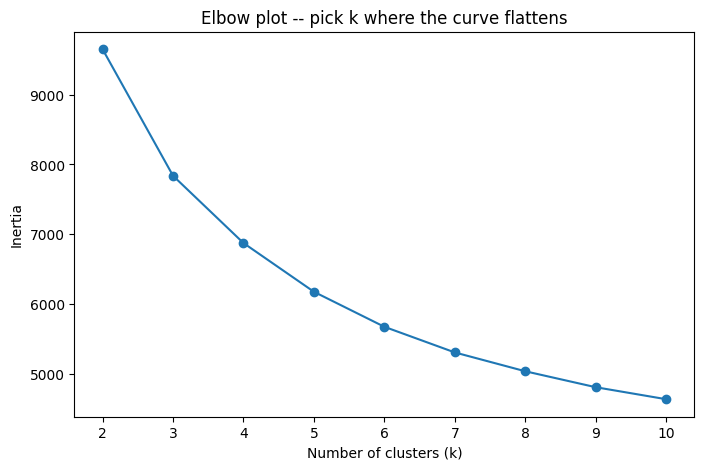

In [7]:
'''Elbow Plot - K-means clustering'''

X = candidate_profiles[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_values = range(2, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow plot -- pick k where the curve flattens")
plt.show()

In [9]:
K = 5  # set from the elbow plot above

kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
candidate_profiles["cluster"] = kmeans.fit_predict(X_scaled)

print(candidate_profiles["cluster"].value_counts().sort_index())
cluster_summary = candidate_profiles.groupby("cluster")[CLUSTER_FEATURES].mean().round(3)
print(cluster_summary)

cluster
0    452
1    183
2     94
3    337
4    438
Name: count, dtype: int64
         npg_per90  npxG_per90  shots_per90  assists_per90  xA_per90  \
cluster                                                                
0            0.147       0.165        1.780          0.170     0.195   
1            0.454       0.526        2.934          0.135     0.143   
2            0.323       0.346        2.751          0.308     0.326   
3            0.221       0.275        2.057          0.070     0.094   
4            0.047       0.067        0.938          0.054     0.070   

         key_passes_per90  xGChain_per90  xGBuildup_per90  xG_per_shot  
cluster                                                                 
0                   1.604          0.527            0.279        0.101  
1                   1.066          0.744            0.189        0.199  
2                   2.272          0.952            0.442        0.138  
3                   0.855          0.431           

## 7. Similarity ranking vs. the Salah target

In [10]:
def rank_by_similarity(candidates: pd.DataFrame, target: pd.Series, scaler) -> pd.DataFrame:
    Xc = scaler.transform(candidates[CLUSTER_FEATURES])
    target_scaled = scaler.transform(pd.DataFrame([target[CLUSTER_FEATURES].values], columns=CLUSTER_FEATURES))
    sims = cosine_similarity(target_scaled, Xc)[0]
    out = candidates.copy()
    out["similarity_to_salah"] = sims
    return out.sort_values("similarity_to_salah", ascending=False).reset_index(drop=True)


ranked = rank_by_similarity(candidate_profiles, salah_target, scaler)
#ranked.to_csv(data_path("salah_replacement_ranked.csv"), index=False)

print(ranked[["player_name", "last_team", "last_league", "total_minutes", "reliability", "cluster", "similarity_to_salah"]].head(25))

               player_name            last_team     last_league  \
0           Tijjani Noslin                Lazio         Serie A   
1          Ousmane Dembélé  Paris Saint Germain         Ligue 1   
2   Matias Fernandez-Pardo                Lille         Ligue 1   
3               Pau Victor            Barcelona         La Liga   
4               Leroy Sané        Bayern Munich      Bundesliga   
5           El Bilal Touré        VfB Stuttgart      Bundesliga   
6            Omar Marmoush      Manchester City  Premier League   
7              Rafael Leão             AC Milan         Serie A   
8           Fisnik Asllani           Hoffenheim      Bundesliga   
9               Cody Gakpo            Liverpool  Premier League   
10            Amine Gouiri            Marseille         Ligue 1   
11         Vinícius Júnior          Real Madrid         La Liga   
12              Harry Kane        Bayern Munich      Bundesliga   
13                Raphinha            Barcelona         La Lig

In [11]:
salah_target_scaled = scaler.transform(pd.DataFrame([salah_target[CLUSTER_FEATURES].values], columns=CLUSTER_FEATURES))
salah_target_cluster = kmeans.predict(salah_target_scaled)[0]

print(f"Mohamed Salah's target profile belongs to Cluster: {salah_target_cluster}")
print("Salah target profile:\n", salah_target)
print("Corresponding cluster summary:\n", cluster_summary.loc[salah_target_cluster])

Mohamed Salah's target profile belongs to Cluster: 2
Salah target profile:
 npg_per90           0.557184
npxG_per90          0.574821
shots_per90         3.885427
assists_per90       0.319452
xA_per90            0.300021
key_passes_per90    1.957572
xGChain_per90       1.012358
xGBuildup_per90     0.284717
xG_per_shot         0.177724
Name: Mohamed Salah target, dtype: float64
Corresponding cluster summary:
 npg_per90           0.323
npxG_per90          0.346
shots_per90         2.751
assists_per90       0.308
xA_per90            0.326
key_passes_per90    2.272
xGChain_per90       0.952
xGBuildup_per90     0.442
xG_per_shot         0.138
Name: 2, dtype: float64


In [12]:
ranked_cluster_2 = ranked[ranked['cluster'] == 2].reset_index(drop=True)
print("Top players in Cluster 2:")
print(ranked_cluster_2[["player_name", "last_team", "total_minutes", "seasons_count", "reliability", "cluster", "similarity_to_salah"]].head(50))

Top players in Cluster 2:
              player_name               last_team  total_minutes  \
0         Ousmane Dembélé     Paris Saint Germain           2797   
1              Pau Victor               Barcelona            273   
2              Leroy Sané           Bayern Munich           1638   
3          El Bilal Touré           VfB Stuttgart            339   
4           Omar Marmoush         Manchester City           3359   
5             Rafael Leão                AC Milan           4203   
6         Vinícius Júnior             Real Madrid           5132   
7                Raphinha               Barcelona           4286   
8         Marcus Rashford               Barcelona           3174   
9               Luis Díaz           Bayern Munich           4897   
10        Bradley Barcola     Paris Saint Germain           4001   
11          Jamal Musiala           Bayern Munich           2488   
12          Ibrahim Mbaye     Paris Saint Germain           1304   
13        Ademola Look

## 8. Visuals

PCA scatter, similarity leaderboard, radar plots for the top 3, a
minutes-vs-similarity check (this is the direct answer to "did removing the
threshold actually surface anyone new"), and feature distributions.

In [11]:
'''Set plot features'''

import matplotlib.font_manager as fm

plt.style.use("default")

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,

    # Axes
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "axes.linewidth": 1.2,

    # Ticks
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,

    # Lines
    "lines.linewidth": 2,

    # Legend
    "legend.frameon": False,
    "legend.fontsize": 12,

    # Figure
    "figure.figsize": (6,4),
    "figure.dpi": 120,

    # Save quality
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

colors = {
    "stokes": "#4C72B0",   # blue
    "mle": "#55A868",      # green
    "nn": "#C44E52"        # red
}

def nice_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

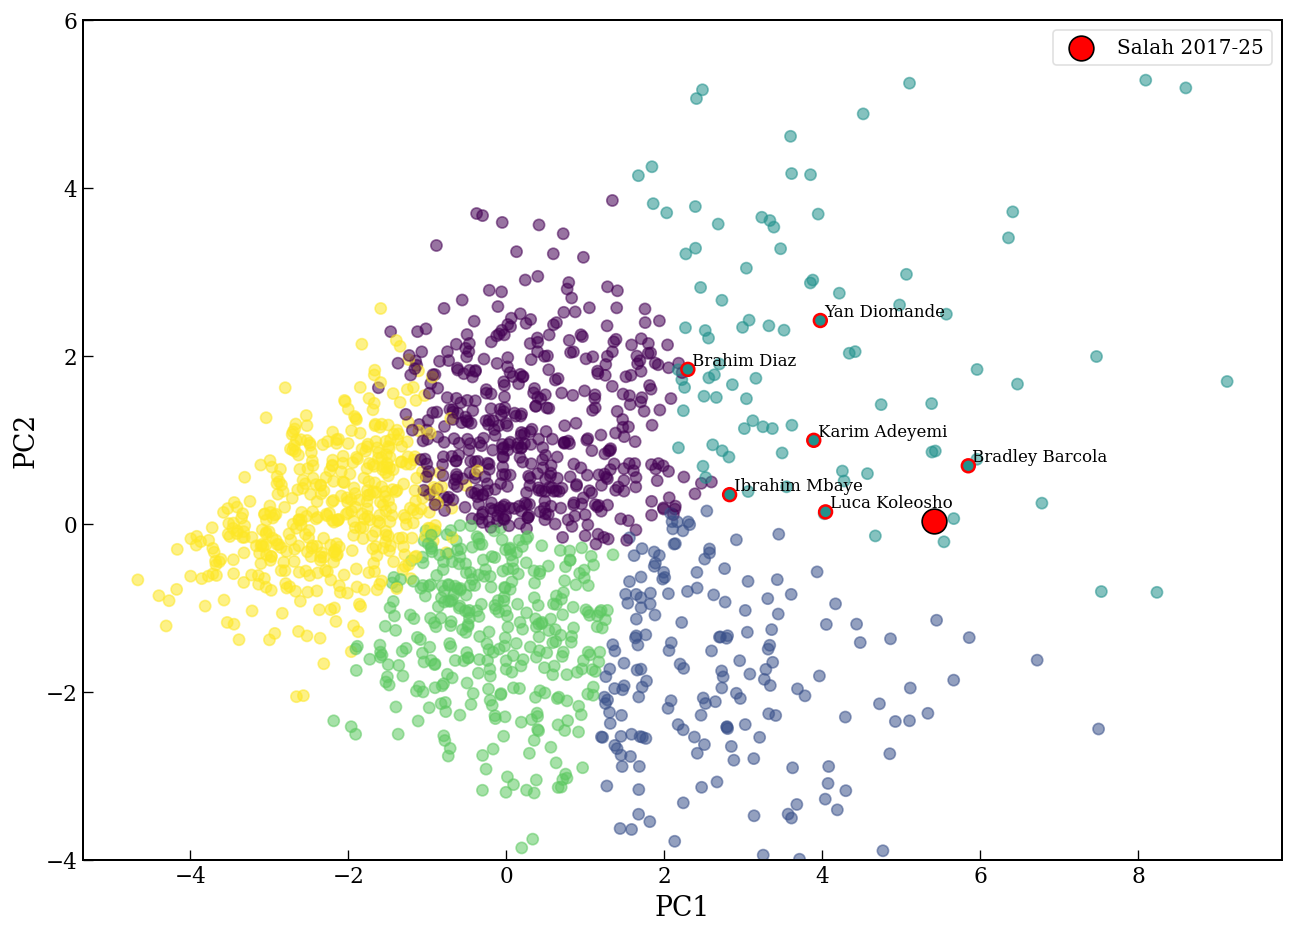

In [17]:
from google.colab import files

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
plot_df = candidate_profiles.copy()
plot_df["PC1"], plot_df["PC2"] = coords[:, 0], coords[:, 1]

salah_scaled = scaler.transform(pd.DataFrame([salah_target[CLUSTER_FEATURES].values], columns=CLUSTER_FEATURES))
salah_pca = pca.transform(salah_scaled)

plt.figure(figsize=(11, 8))
scatter = plt.scatter(plot_df["PC1"], plot_df["PC2"], c=plot_df["cluster"], cmap="viridis", alpha=0.55, s=45)

# Manually select player names to display on the PCA plot
selected_pca_names = ['Ibrahim Mbaye', 'Brahim Diaz', 'Bradley Barcola', 'Yan Diomande', 'Karim Adeyemi', 'Luca Koleosho']

# Plot selected players with a red outline
selected_players_plot_df = plot_df[plot_df["player_name"].isin(selected_pca_names)]

# Get the viridis colormap
import matplotlib.cm as cm
cmap = plt.get_cmap('viridis', K) # Updated from cm.get_cmap

# Get the specific colors for the selected players based on their cluster
selected_player_colors = [cmap(cluster_id) for cluster_id in selected_players_plot_df["cluster"]]

plt.scatter(selected_players_plot_df["PC1"], selected_players_plot_df["PC2"],
            c=selected_player_colors, # Use the specific cluster colors
            s=60, # Slightly larger size for visibility
            edgecolors='red', linewidth=1.5, zorder=4) # Red outline, higher zorder

plt.scatter(salah_pca[:, 0], salah_pca[:, 1], color="red", s=220, edgecolors="black", zorder=5, label="Salah 2017-25")

for _, row in plot_df[plot_df["player_name"].isin(selected_pca_names)].iterrows():
    plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, row["player_name"], fontsize=10)

plt.xlabel("PC1"); plt.ylabel("PC2")
plt.ylim(-4, 6)
#plt.title("Candidate similarity space (PCA of clustering features)")
plt.legend(frameon=True, framealpha=0.6); plt.tight_layout()
plt.savefig("pca_plot.png")
files.download("pca_plot.png")
plt.show()

In [25]:
import plotly.express as px
import plotly.graph_objects as go # Import go for Scatter trace
import matplotlib.cm as cm # Import cm to get viridis colormap

# Re-create plot_df for PCA context, as it might have been overwritten by other cells.
# This ensures 'PC1' and 'PC2' are present.
# pca, X_scaled, candidate_profiles, and ranked are expected to be available from previous cell executions.
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
plot_df_pca = candidate_profiles.copy()
plot_df_pca["PC1"], plot_df_pca["PC2"] = coords[:, 0], coords[:, 1]

# Ensure plot_df_pca contains the 'similarity_to_salah' column for hover data
if 'similarity_to_salah' not in plot_df_pca.columns:
    plot_df_pca = plot_df_pca.merge(ranked[['player_name', 'similarity_to_salah']], on='player_name', how='left')

# Create a discrete color map for clusters to match the static plot and hide the colorbar
# K is the number of clusters, defined earlier in the notebook
cmap = plt.get_cmap('viridis', K)
cluster_colors = {str(i): f'rgba({int(c[0]*255)},{int(c[1]*255)},{int(c[2]*255)},{c[3]})' for i, c in enumerate(cmap(np.linspace(0, 1, K)))}

# Create an interactive PCA scatter plot using Plotly
fig_interactive_pca = px.scatter(
    plot_df_pca, # Use the PCA-specific dataframe
    x="PC1",
    y="PC2",
    color="cluster", # Color points by cluster
    color_discrete_map=cluster_colors, # Use discrete colors for clusters
    hover_name="player_name", # Show player name on hover
    hover_data={
        "PC1": ':.2f', # Format PC1 on hover
        "PC2": ':.2f', # Format PC2 on hover
        "cluster": True,
        "last_team": True,
        "last_league": True,
        "reliability": True,
        "total_minutes": True,
        "similarity_to_salah": ':.3f' # Show similarity on hover
    },
    #title="Interactive PCA Plot: Hover to Identify Players",
    labels={
        "PC1": "Principal Component 1",
        "PC2": "Principal Component 2",
        "cluster": "Cluster"
    }
)

# Add Salah's target profile to the interactive plot
# salah_pca is expected to be available from cell 69ae9db4.
fig_interactive_pca.add_trace(go.Scatter(
    x=[salah_pca[:, 0][0]],
    y=[salah_pca[:, 1][0]],
    mode='markers',
    marker=dict(size=20, color='red', symbol='star', line=dict(width=2, color='Black')),
    name='Salah 2017-25',
    hoverinfo='name'
))

# Highlight 'Bradley Barcola'
highlighted_player_name = "Bradley Barcola"
highlighted_player_data = plot_df_pca[plot_df_pca['player_name'] == highlighted_player_name] # Use plot_df_pca here

if not highlighted_player_data.empty:
    fig_interactive_pca.add_trace(go.Scatter(
        x=highlighted_player_data["PC1"],
        y=highlighted_player_data["PC2"],
        mode='markers',
        marker=dict(
            size=15, # Larger size
            color='rgba(0,0,0,0)', # Transparent fill
            line=dict(width=2, color='magenta') # Magenta border
        ),
        name=f'{highlighted_player_name}',
        showlegend=True, # Show in legend
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "PC1: %{x:.2f}<br>" +
            "PC2: %{y:.2f}<br>" +
            "Cluster: %{customdata[0]}<br>" +
            "Last Team: %{customdata[1]}<br>" +
            "Last League: %{customdata[2]}<br>" +
            "Reliability: %{customdata[3]}<br>" +
            "Total Minutes: %{customdata[4]}<br>" +
            "Similarity to Salah: %{customdata[5]:.3f}"
            "<extra></extra>"
        ),
        text=[highlighted_player_name],
        customdata=highlighted_player_data[[
            "cluster", "last_team", "last_league", "reliability", "total_minutes", "similarity_to_salah"
        ]].values
    ))

fig_interactive_pca.update_layout(height=600,
                                  coloraxis_showscale=False, # Explicitly hide the colorbar
                                  title=f"Interactive PCA Plot") # Update title
fig_interactive_pca.show()

# Save the interactive Plotly figure to an HTML file
output_html_path = data_path("interactive_pca_plot.html")
fig_interactive_pca.write_html(output_html_path)
print(f"Interactive PCA plot saved to: {output_html_path}")

Interactive PCA plot saved to: /content/drive/MyDrive/Football_Projects/salah_replacement/interactive_pca_plot.html


This interactive plot allows you to hover over any point to reveal the player's name, team, league, reliability, total minutes, and similarity to Salah. You can zoom in and out, and pan around to explore specific regions of the plot in detail.

Manually selected candidates for radar plot: ['Bradley Barcola', 'Ibrahim Mbaye', 'Luca Koleosho', 'Karim Adeyemi', 'Yan Diomande', 'Brahim Diaz']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

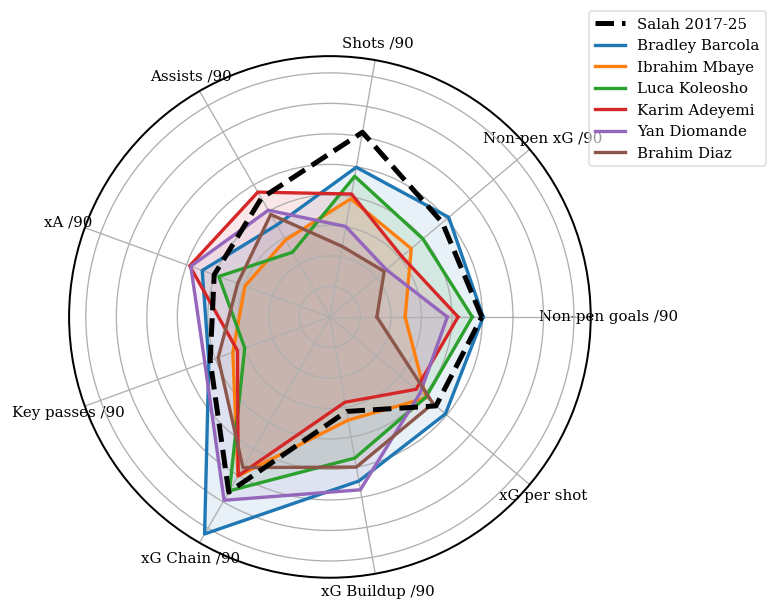

In [29]:
from google.colab import files

FEATURE_LABELS = {
    "npg_per90": "Non-pen goals /90", "npxG_per90": "Non-pen xG /90", "shots_per90": "Shots /90",
    "assists_per90": "Assists /90", "xA_per90": "xA /90", "key_passes_per90": "Key passes /90",
    "xGChain_per90": "xG Chain /90", "xGBuildup_per90": "xG Buildup /90", "xG_per_shot": "xG per shot",
}

# Define distinct colors for candidates. Use a palette that offers enough variety.
# Moved outside the function so it can be accessed globally if needed.
DEFAULT_CANDIDATE_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

def radar_chart(players_df, target, name_col="player_name", features=None, global_min=None, global_max=None, player_colors_override_map=None):
    features = features or CLUSTER_FEATURES

    # Ensure players_df has a clean, sequential index for direct iloc access
    players_df_for_norm = players_df[features].reset_index(drop=True)

    all_rows = pd.concat([
        players_df_for_norm,
        pd.DataFrame([target[features].values], columns=features),
    ], ignore_index=True)

    if global_min is None or global_max is None:
        mins, maxs = all_rows.min(), all_rows.max()
    else:
        mins = global_min[features]
        maxs = global_max[features]

    normed = (all_rows - mins) / (maxs - mins).replace(0, 1)

    labels = [FEATURE_LABELS.get(f, f) for f in features]
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    # Plot Salah target first, ensuring it's always visible and on top
    salah_values = normed.iloc[len(players_df_for_norm)].tolist(); salah_values += salah_values[:1]
    ax.plot(angles, salah_values, linewidth=3, linestyle="--", color="black", label="Salah 2017-25", zorder=10)

    # Plot candidates after Salah target, with fill having lower zorder than line
    for i in range(len(players_df_for_norm)):
        player_name = players_df.iloc[i][name_col]
        values = normed.iloc[i].tolist(); values += values[:1]

        # Use override color if provided, otherwise cycle through default colors
        if player_colors_override_map and player_name in player_colors_override_map:
            color = player_colors_override_map[player_name]
        else:
            color = DEFAULT_CANDIDATE_COLORS[i % len(DEFAULT_CANDIDATE_COLORS)] # Cycle through colors

        ax.plot(angles, values, linewidth=2, label=player_name, color=color, zorder=5)
        ax.fill(angles, values, alpha=0.1, color=color, zorder=1) # Fill has lower zorder

    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels([])#; ax.set_title(title, fontsize=13, pad=20)
    ax.legend(loc="upper right", frameon=True, framealpha=0.6, bbox_to_anchor=(1.35, 1.1), fontsize=9)
    fig.tight_layout()
    return fig


# Calculate global min/max from the entire candidate pool (X DataFrame)
global_min_features = X[CLUSTER_FEATURES].min()
global_max_features = X[CLUSTER_FEATURES].max()

# Filter the ranked DataFrame for the selected players
manual_top_candidates_for_radar = ranked[ranked['player_name'].isin(selected_pca_names)]
print("Manually selected candidates for radar plot:", manual_top_candidates_for_radar["player_name"].tolist())

# Call for the combined plot (no override map needed here, it uses the default cycling)
radar_chart(manual_top_candidates_for_radar, salah_target, global_min=global_min_features, global_max=global_max_features)
plt.savefig("combined_radar_plot.png")
files.download("combined_radar_plot.png")
plt.show()

### Individual Radar Plots: Salah vs. Each Selected Candidate

Radar plot: Bradley Barcola vs. Salah 2017-25


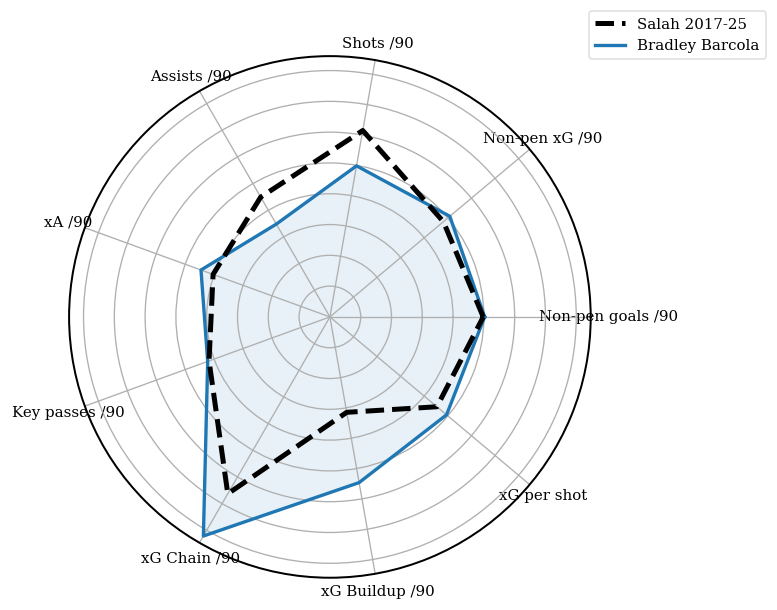

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Radar plot: Ibrahim Mbaye vs. Salah 2017-25


<Figure size 720x480 with 0 Axes>

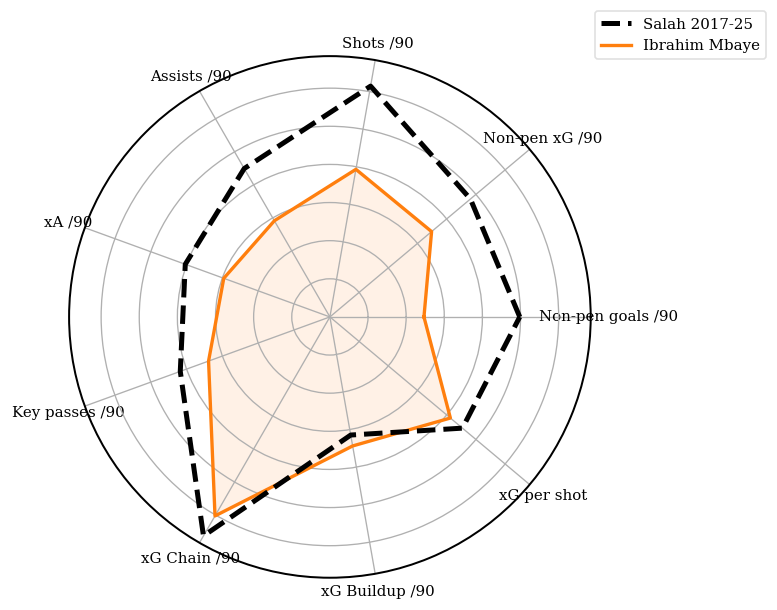

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Radar plot: Luca Koleosho vs. Salah 2017-25


<Figure size 720x480 with 0 Axes>

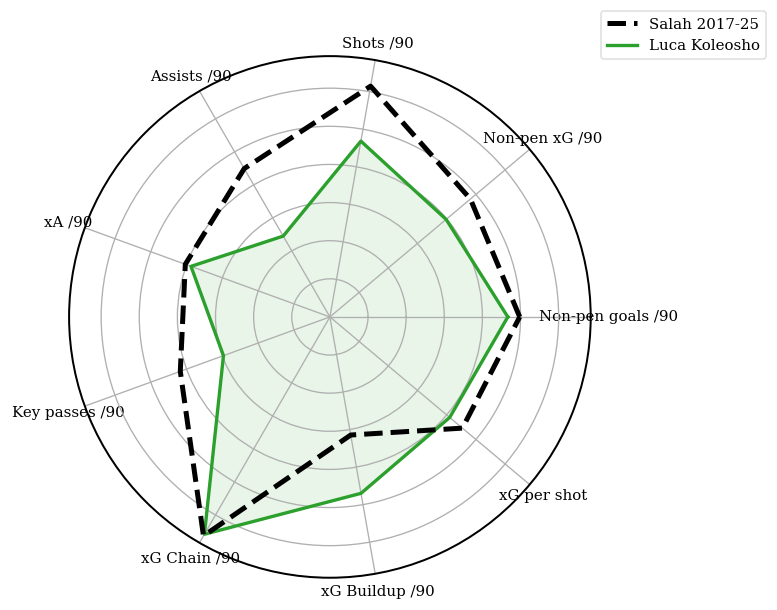

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Radar plot: Karim Adeyemi vs. Salah 2017-25


<Figure size 720x480 with 0 Axes>

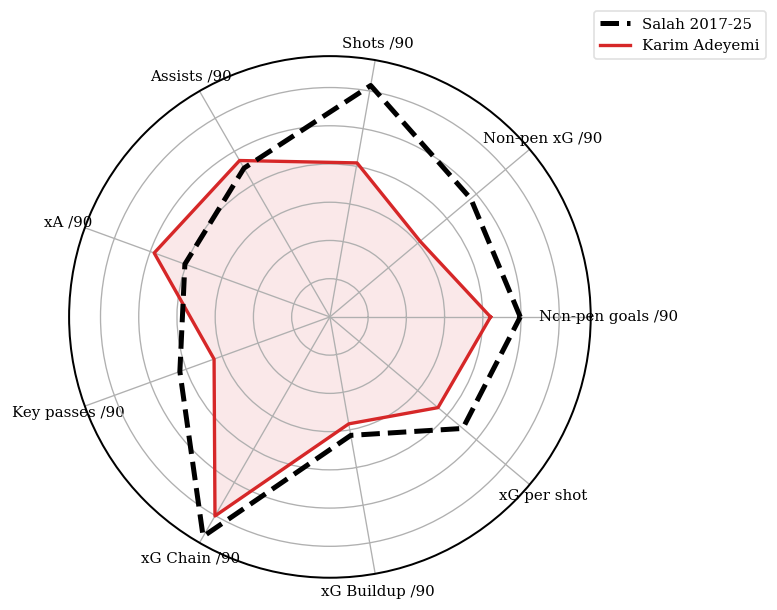

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Radar plot: Yan Diomande vs. Salah 2017-25


<Figure size 720x480 with 0 Axes>

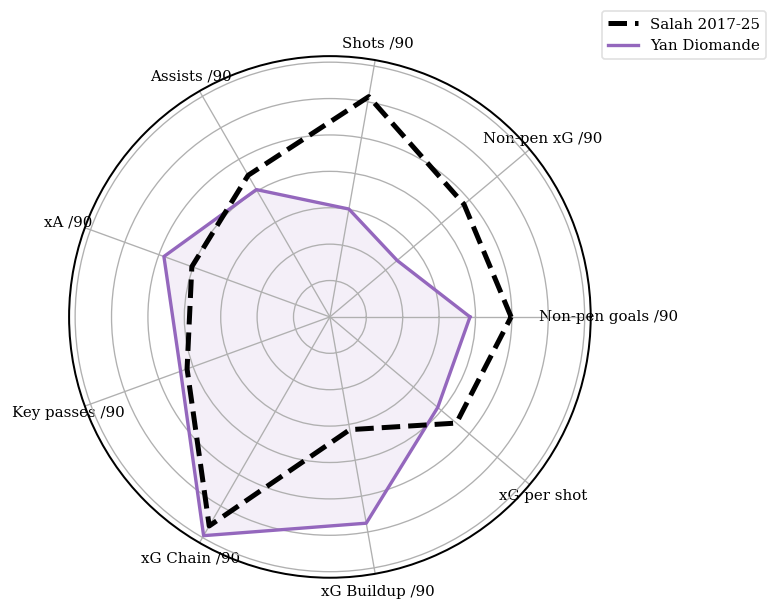

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Radar plot: Brahim Diaz vs. Salah 2017-25


<Figure size 720x480 with 0 Axes>

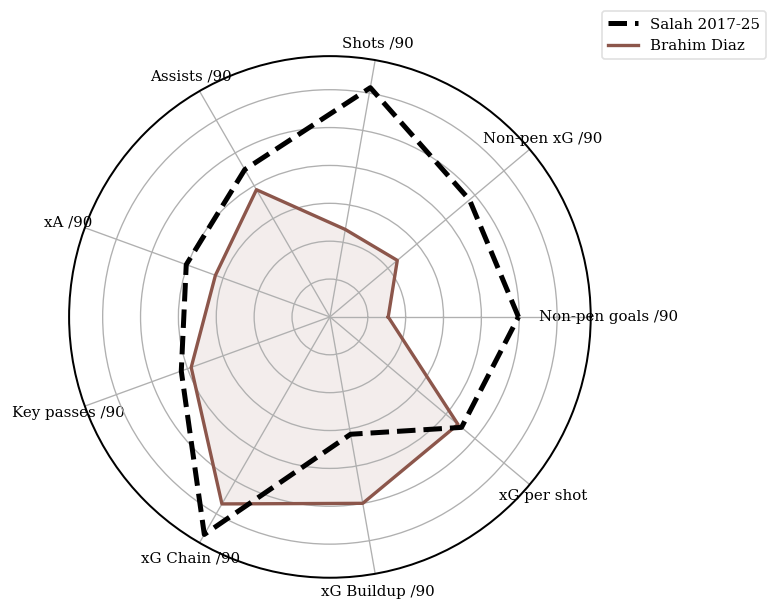

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 720x480 with 0 Axes>

In [30]:
# Create a mapping of player names to their assigned colors from the combined plot
player_color_map_for_individuals = {}
for i, (_, row) in enumerate(manual_top_candidates_for_radar.iterrows()):
    player_name = row['player_name']
    player_color_map_for_individuals[player_name] = DEFAULT_CANDIDATE_COLORS[i % len(DEFAULT_CANDIDATE_COLORS)]

for _, player_row in manual_top_candidates_for_radar.iterrows():
    player_name = player_row['player_name']
    # Create a DataFrame for a single player
    single_player_df = pd.DataFrame([player_row])

    print(f"Radar plot: {player_name} vs. Salah 2017-25")
    radar_chart(
        single_player_df,
        salah_target,
        #title=f"{player_name} vs. Salah target",
        global_min=global_min_features,
        global_max=global_max_features,
        player_colors_override_map=player_color_map_for_individuals # Pass the color map here
    )
    plt.show()
    plt.savefig(f"{player_name}_radar_plot.png")
    files.download(f"{player_name}_radar_plot.png")

In [62]:
import matplotlib.cm as cm

# --- Simple stat-vs-stat scatters: which players sit closest to Salah on just two axes ---
# Complements the PCA/similarity views: easier to screenshot and explain, and sometimes
# surfaces players who are close on a specific trait pair but get buried in the 13-D similarity score.

def feature_pair_scatter(x_feat, y_feat, top_n=8, title=None, highlight_names=None):
    x_all = pd.concat([candidate_profiles[x_feat], pd.Series([salah_target[x_feat]])], ignore_index=True)
    y_all = pd.concat([candidate_profiles[y_feat], pd.Series([salah_target[y_feat]])], ignore_index=True)
    x_norm = (x_all - x_all.min()) / (x_all.max() - x_all.min())
    y_norm = (y_all - y_all.min()) / (y_all.max() - y_all.min())

    cand_x, cand_y = x_norm.iloc[:-1], y_norm.iloc[:-1]
    salah_x, salah_y = x_norm.iloc[-1], y_norm.iloc[-1]

    # Determine which players to highlight
    if highlight_names is not None and len(highlight_names) > 0:
        # Filter candidate_profiles by highlight_names to get their original indices
        players_to_annotate_df = candidate_profiles[candidate_profiles['player_name'].isin(highlight_names)]
    else:
        # Nearest-to-Salah in THIS pair specifically (min-max normalized so neither axis dominates)
        dist = np.sqrt((cand_x - salah_x) ** 2 + (cand_y - salah_y) ** 2)
        nearest_indices = dist.nsmallest(top_n).index
        players_to_annotate_df = candidate_profiles.iloc[nearest_indices]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(candidate_profiles[x_feat], candidate_profiles[y_feat],
               c=candidate_profiles["cluster"], cmap="viridis", alpha=0.55, s=45)
    ax.scatter(salah_target[x_feat], salah_target[y_feat], color="red", s=220,
               edgecolors="black", zorder=5, label="Salah 2017-25")

    # Plot highlighted players with a red border on top
    if highlight_names is not None and len(highlight_names) > 0:
        highlighted_plot_df = candidate_profiles[candidate_profiles['player_name'].isin(highlight_names)]

        # Get the viridis colormap and apply it for the highlighted players
        cmap = plt.get_cmap('viridis', K) # K is the number of clusters, available globally
        highlighted_colors = [cmap(cluster_id) for cluster_id in highlighted_plot_df["cluster"]]

        ax.scatter(highlighted_plot_df[x_feat], highlighted_plot_df[y_feat],
                   c=highlighted_colors, # Use their original cluster colors
                   s=65, # Slightly larger size for visibility
                   edgecolors='red', linewidth=1.5, zorder=4) # Red outline, higher zorder

    for _, row in players_to_annotate_df.iterrows():
        ax.annotate(row["player_name"], (row[x_feat], row[y_feat]), fontsize=12,
                    xytext=(4, 4), textcoords="offset points")

    ax.set_xlabel(FEATURE_LABELS.get(x_feat, x_feat))
    ax.set_ylabel(FEATURE_LABELS.get(y_feat, y_feat))
    #ax.set_xlim(0, 0.7)
    #ax.set_ylim(0, 0.9)
    ax.set_title(title or f"{FEATURE_LABELS.get(x_feat, x_feat)} vs. {FEATURE_LABELS.get(y_feat, y_feat)}")
    ax.legend(frameon=True, framealpha=0.6, bbox_to_anchor=(1.0, 1))
    fig.tight_layout()
    plt.show()
    return players_to_annotate_df[["player_name", x_feat, y_feat]]

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

def feature_pair_scatter_plotly(x_feat, y_feat, title=None, highlight_names=None,
                                  plot_df=candidate_profiles, salah_target=salah_target, K=K):

    fig = px.scatter(plot_df,
                     x=x_feat,
                     y=y_feat,
                     color="cluster",
                     hover_name="player_name",
                     hover_data={
                         x_feat: ':.3f',
                         y_feat: ':.3f',
                         "cluster": True,
                         "last_team": True,
                         "last_league": True,
                         "reliability": True,
                         "total_minutes": True,
                         "similarity_to_salah": ':.3f'
                     },
                     title=title or f"{FEATURE_LABELS.get(x_feat, x_feat)} vs. {FEATURE_LABELS.get(y_feat, y_feat)}",
                     labels={
                         x_feat: FEATURE_LABELS.get(x_feat, x_feat),
                         y_feat: FEATURE_LABELS.get(y_feat, y_feat),
                         "cluster": "Cluster"
                     },
                     color_continuous_scale=px.colors.sequential.Viridis # Match matplotlib cmap
                    )

    # Add Salah's target
    fig.add_trace(go.Scatter(
        x=[salah_target[x_feat]],
        y=[salah_target[y_feat]],
        mode='markers',
        marker=dict(size=15, color='red', symbol='star', line=dict(width=1, color='Black')),
        name='Salah Target',
        hoverinfo='name'
    ))

    # Add highlighted players with a red border
    if highlight_names is not None and len(highlight_names) > 0:
        highlighted_plot_df = plot_df[plot_df['player_name'].isin(highlight_names)]

        if not highlighted_plot_df.empty:
            # Get cluster colors for highlighted players
            cmap = plt.get_cmap('viridis', K)
            highlighted_colors = [f'rgba({int(c[0]*255)}, {int(c[1]*255)}, {int(c[2]*255)}, {c[3]})'
                                  for c in [cmap(cluster_id) for cluster_id in highlighted_plot_df["cluster"]]]

            fig.add_trace(go.Scatter(
                x=highlighted_plot_df[x_feat],
                y=highlighted_plot_df[y_feat],
                mode='markers',
                marker=dict(
                    size=10,
                    color=highlighted_colors, # Use their original cluster colors
                    line=dict(width=1.5, color='red') # Red border
                ),
                name='Highlighted Players',
                showlegend=False,
                text=highlighted_plot_df["player_name"],
                hovertemplate=(
                    "<b>%{text}</b><br>" +
                    f"{FEATURE_LABELS.get(x_feat, x_feat)}: %{{x:.3f}}<br>" +
                    f"{FEATURE_LABELS.get(y_feat, y_feat)}: %{{y:.3f}}<br>" +
                    "Cluster: %{{customdata[0]}}"<br>" +
                    "Last Team: %{{customdata[1]}}"<br>" +
                    "Last League: %{{customdata[2]}}"<br>" +
                    "Reliability: %{{customdata[3]}}"<br>" +
                    "Total Minutes: %{{customdata[4]}}"<br>" +
                    "Similarity to Salah: %{{customdata[5]:.3f}}"
                    "<extra></extra>"
                ),
                customdata=highlighted_plot_df[[
                    "cluster", "last_team", "last_league", "reliability", "total_minutes", "similarity_to_salah"
                ]].values
            ))
    fig.update_layout(height=600)
    return fig

In [ ]:
# Goal threat vs. creativity
fig_goal_threat = feature_pair_scatter_plotly("npxG_per90", "xA_per90",
                                            highlight_names=["Mohamed Salah", "Bradley Barcola", "Yan Diomande", "Michael Olise", "Ibrahim Mbaye", "Luca Koleosho"],
                                            title="Goal threat vs. creativity")
fig_goal_threat.show()


In [ ]:
# Shot Volume vs. Quality
fig_shot_volume = feature_pair_scatter_plotly("shots_per90", "xG_per_shot",
                                            highlight_names=["Mohamed Salah", "Bradley Barcola", "Yan Diomande", "Ibrahim Mbaye"],
                                            title="Shot Volume vs. Quality")
fig_shot_volume.show()

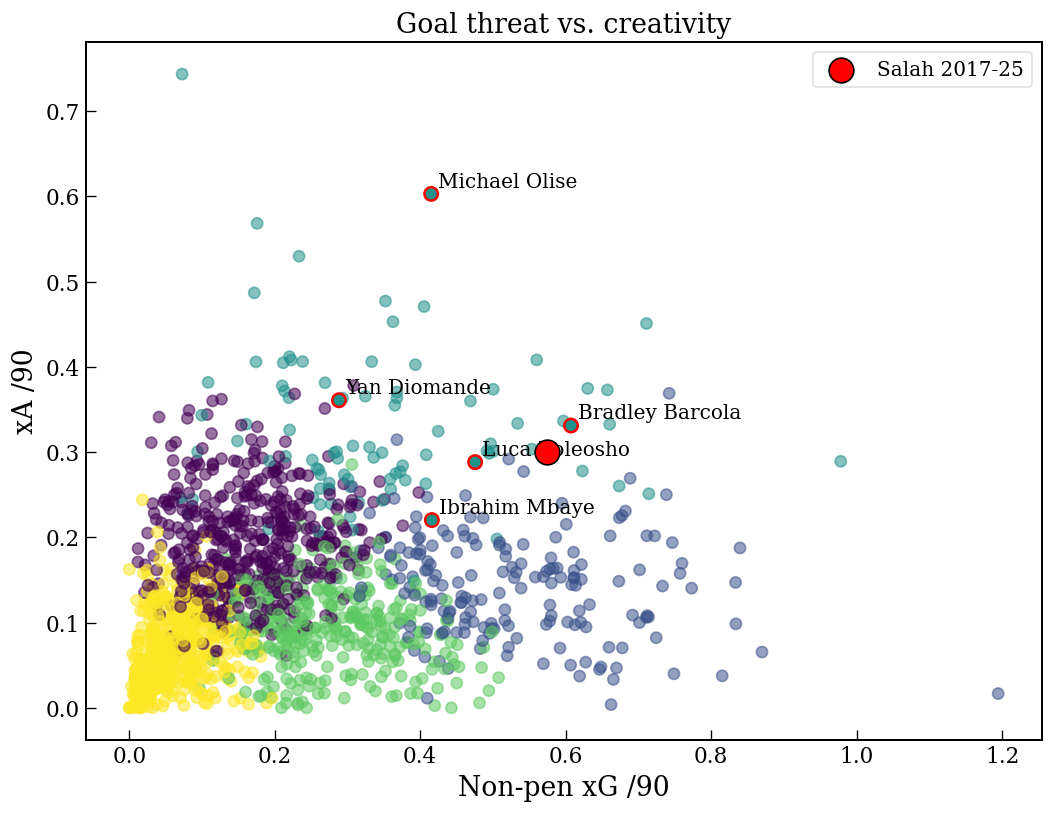

,player_name,npxG_per90,xA_per90
215,Bradley Barcola,0.607318,0.331062
575,Ibrahim Mbaye,0.415982,0.220173
856,Luca Koleosho,0.475503,0.288188
994,Michael Olise,0.415060,0.602784
1458,Yan Diomande,0.288280,0.360749


In [68]:
feature_pair_scatter("npxG_per90", "xA_per90",
                     highlight_names=["Mohamed Salah", "Bradley Barcola", "Yan Diomande", "Michael Olise", "Ibrahim Mbaye", "Luca Koleosho"],
                     title="Goal threat vs. creativity")

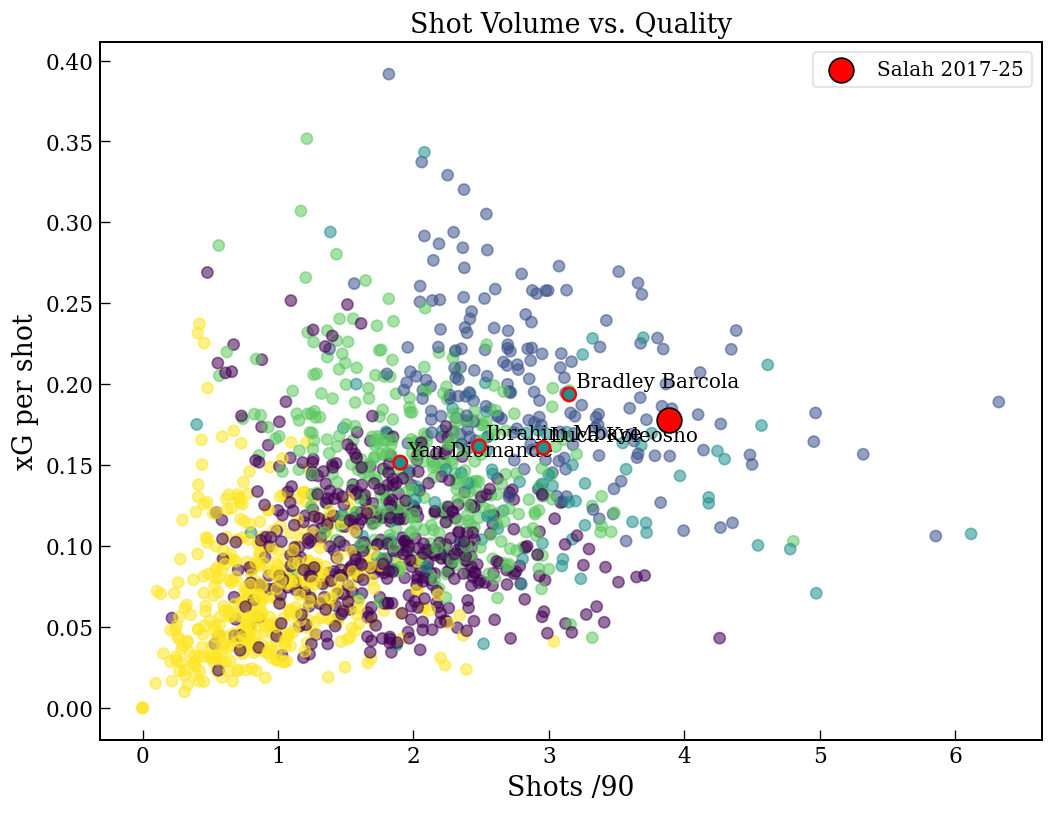

,player_name,shots_per90,xG_per_shot
215,Bradley Barcola,3.149213,0.193679
575,Ibrahim Mbaye,2.484663,0.161563
856,Luca Koleosho,2.959381,0.160677
1458,Yan Diomande,1.902673,0.151513


In [66]:
feature_pair_scatter("shots_per90", "xG_per_shot",
                     highlight_names=["Mohamed Salah", "Bradley Barcola", "Yan Diomande", "Ibrahim Mbaye"],
                     title="Shot Volume vs. Quality")

In [57]:
import plotly.express as px
import plotly.graph_objects as go

# Ensure candidate_profiles contains the 'similarity_to_salah' column for hover data.
# It is generated in the 'ranked' DataFrame, so we merge it here.
if 'similarity_to_salah' not in candidate_profiles.columns:
    candidate_profiles = candidate_profiles.merge(ranked[['player_name', 'similarity_to_salah']], on='player_name', how='left')

# Get the list of players to highlight from the static plot, excluding Salah as he's already a target
highlight_names = ["Bradley Barcola", "Yan Diomande", "Michael Olise", "Ibrahim Mbaye"]
highlighted_players_df = candidate_profiles[candidate_profiles['player_name'].isin(highlight_names)].copy()

# Create an interactive scatter plot for npxG_per90 vs xA_per90 using Plotly Express
fig_interactive_npxG_xA = px.scatter(
    candidate_profiles,
    x="npxG_per90",
    y="xA_per90",
    color="cluster", # Color points by cluster
    hover_name="player_name", # Show player name on hover
    hover_data={
        "npxG_per90": ':.3f',
        "xA_per90": ':.3f',
        "cluster": True,
        "last_team": True,
        "last_league": True,
        "reliability": True,
        "total_minutes": True,
        "similarity_to_salah": ':.3f' # Now similarity_to_salah is ensured to be in candidate_profiles
    },
    title="Interactive: Non-pen xG /90 vs. xA /90 (Goal Threat vs. Creativity)",
    labels={
        "npxG_per90": "Non-pen xG /90",
        "xA_per90": "xA /90",
        "cluster": "Cluster"
    },
    color_continuous_scale=px.colors.sequential.Viridis # Use a sequential color scale matching viridis
)

# Add Salah's target profile to the interactive plot
fig_interactive_npxG_xA.add_trace(go.Scatter(
    x=[salah_target["npxG_per90"]],
    y=[salah_target["xA_per90"]],
    mode='markers',
    marker=dict(size=20, color='red', symbol='star', line=dict(width=2, color='Black')),
    name='Salah Target',
    hoverinfo='name'
))

# Add highlighted players with a ring around them
if not highlighted_players_df.empty:
    fig_interactive_npxG_xA.add_trace(go.Scatter(
        x=highlighted_players_df["npxG_per90"],
        y=highlighted_players_df["xA_per90"],
        mode='markers',
        marker=dict(size=12, color='rgba(0,0,0,0)', line=dict(width=2, color='Black')),
        name='Highlighted Players',
        showlegend=False, # Don't show this trace in the legend, as players are also colored by cluster
        text=highlighted_players_df["player_name"], # Use text for individual player names on hover
        customdata=highlighted_players_df[[
            "cluster", "last_team", "last_league", "reliability", "total_minutes", "similarity_to_salah"
        ]].values,
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Non-pen xG /90: %{x:.3f}<br>" +
            "xA /90: %{y:.3f}<br>" +
            "Cluster: %{customdata[0]}<br>" +
            "Last Team: %{customdata[1]}<br>" +
            "Last League: %{customdata[2]}<br>" +
            "Reliability: %{customdata[3]}<br>" +
            "Total Minutes: %{customdata[4]}<br>" +
            "Similarity to Salah: %{customdata[5]:.3f}"
            "<extra></extra>" # This hides the default trace name from the hover box
        )
    ))

# Add median lines for context
x_median = candidate_profiles["npxG_per90"].median()
y_median = candidate_profiles["xA_per90"].median()

fig_interactive_npxG_xA.add_shape(
    type="line",
    x0=x_median, y0=candidate_profiles["xA_per90"].min(),
    x1=x_median, y1=candidate_profiles["xA_per90"].max(),
    line=dict(color="grey", dash="dot", width=1)
)

fig_interactive_npxG_xA.add_shape(
    type="line",
    x0=candidate_profiles["npxG_per90"].min(), y0=y_median,
    x1=candidate_profiles["npxG_per90"].max(), y1=y_median,
    line=dict(color="grey", dash="dot", width=1)
)

fig_interactive_npxG_xA.update_layout(height=600)
fig_interactive_npxG_xA.show()

Let's see where Salah would fall if we only considered his last two seasons, similar to the candidate pool generation.

In [ ]:
# Filter Salah's data for the candidate seasons (last two seasons)
salah_df_last_two_seasons = salah_df[salah_df["season"].isin(CANDIDATE_SEASONS)].copy()

# Build a target vector for Salah based on these two seasons
# Using the CANDIDATE_WEIGHTS to be consistent with candidate profile generation
salah_target_last_two_seasons = build_target_vector(salah_df_last_two_seasons, CANDIDATE_WEIGHTS, "Mohamed Salah (last two seasons)")

# Scale this new target vector
salah_target_last_two_seasons_scaled = scaler.transform(pd.DataFrame([salah_target_last_two_seasons[CLUSTER_FEATURES].values], columns=CLUSTER_FEATURES))

# Predict the cluster for Salah based on his last two seasons
salah_cluster_last_two_seasons = kmeans.predict(salah_target_last_two_seasons_scaled)[0]

print(f"Mohamed Salah's profile for the last two seasons belongs to Cluster: {salah_cluster_last_two_seasons}")
print("Salah target profile (last two seasons):\n", salah_target_last_two_seasons)
print("Corresponding cluster summary:\n", cluster_summary.loc[salah_cluster_last_two_seasons])

Mohamed Salah's profile for the last two seasons belongs to Cluster: 2
Salah target profile (last two seasons):
 npg_per90           0.406021
npxG_per90          0.456978
shots_per90         3.155887
assists_per90       0.394947
xA_per90            0.352773
key_passes_per90    2.218349
xGChain_per90       1.037234
xGBuildup_per90     0.355510
xG_per_shot         0.177101
Name: Mohamed Salah (last two seasons), dtype: float64
Corresponding cluster summary:
 npg_per90           0.324
npxG_per90          0.345
shots_per90         2.749
assists_per90       0.311
xA_per90            0.326
key_passes_per90    2.284
xGChain_per90       0.952
xGBuildup_per90     0.442
xG_per_shot         0.137
Name: 2, dtype: float64


In [ ]:
def minutes_vs_similarity(ranked_df):
    """Direct visual answer to the old minutes-threshold problem: shows
    whether a high ranking is backed by a big sample or a small one, instead
    of hiding low-minute players from the analysis entirely."""
    color_map = {"High": "#2a6f97", "Medium": "#89c2d9", "Low": "#e07a5f"}
    fig, ax = plt.subplots(figsize=(8, 6))
    for rel, group in ranked_df.groupby("reliability"):
        ax.scatter(group["total_minutes"], group["similarity_to_salah"], label=rel,
                   color=color_map.get(rel, "#999"), alpha=0.75, s=55, edgecolors="white")
    ax.set_xlabel("Total minutes in candidate window")
    ax.set_ylabel("Similarity to Salah target")
    ax.set_title("Similarity vs. sample size -- nobody silently excluded")
    ax.legend(title="Reliability")
    fig.tight_layout()
    return fig

minutes_vs_similarity(ranked)
plt.show()

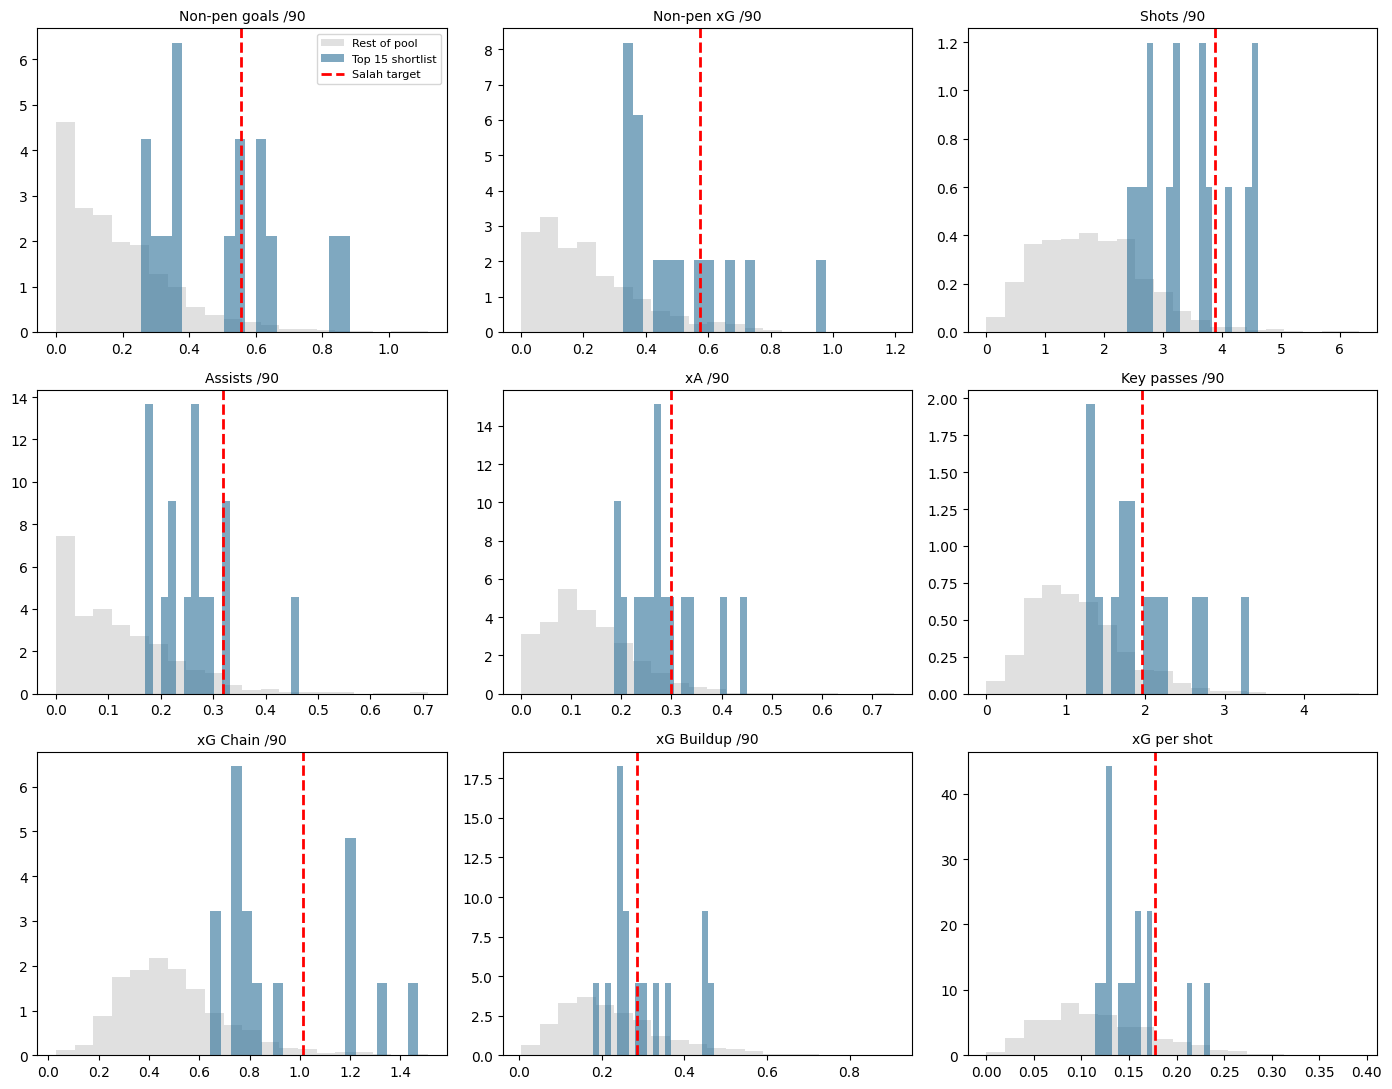

In [ ]:
# Feature-by-feature distribution across the top 15 vs. the rest, Salah marked
top15_names = ranked.head(15)["player_name"].tolist()
plot_data = candidate_profiles.copy()
plot_data["group"] = np.where(plot_data["player_name"].isin(top15_names), "Top 15 shortlist", "Rest of pool")

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, feature in zip(axes.flat, CLUSTER_FEATURES):
    for group, color in [("Rest of pool", "#cccccc"), ("Top 15 shortlist", "#2a6f97")]:
        subset = plot_data[plot_data["group"] == group][feature]
        ax.hist(subset, bins=20, alpha=0.6, label=group, color=color, density=True)
    ax.axvline(salah_target[feature], color="red", linestyle="--", linewidth=2, label="Salah target")
    ax.set_title(FEATURE_LABELS.get(feature, feature), fontsize=10)
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Transfermarkt analysis: value over time & age curves

Transfermarkt has no official API, so this scrapes public pages/endpoints.
**Caveat:** this could not be tested against the live site from this
notebook's original build environment -- run it cell-by-cell the first time
and check output before trusting it at scale. Rate-limited on purpose (2-4s
between requests) and results are cached to CSV so re-runs are cheap.

In [ ]:
import requests
from bs4 import BeautifulSoup

TM_HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"),
    "Accept-Language": "en-GB,en;q=0.9",
}
SEARCH_URL = "https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche"
VALUE_HISTORY_URL = "https://www.transfermarkt.com/ceapi/marketValueDevelopment/graph/{player_id}"
PROFILE_URL = "https://www.transfermarkt.com/{slug}/profil/spieler/{player_id}"


def _polite_get(session, url, **kwargs):
    resp = session.get(url, headers=TM_HEADERS, timeout=20, **kwargs)
    resp.raise_for_status()
    time.sleep(random.uniform(2, 4))
    return resp


def tm_search_player(session, player_name):
    print(f"Searching for player: {player_name}")
    search_params = {"query": player_name}
    search_url_full = f"{SEARCH_URL}?query={player_name}"
    print(f"  Search URL: {search_url_full}")

    resp = _polite_get(session, SEARCH_URL, params=search_params)
    print(f"  Response text length: {len(resp.text)}")
    soup = BeautifulSoup(resp.text, "html.parser")
    print(f"  Soup object length (str): {len(str(soup))}")

    link = soup.select_one("table.items td.hauptlink a[href*='/profil/spieler/']")

    if link is None:
        print(f"  No direct search result link found for {player_name}")
        print("  ------ HTML content of search results page (truncated) ------")
        # Print first 2000 characters of the soup for debugging, to avoid overwhelming output
        print(str(soup)[:2000])
        print("  ------------------------------------------------------------")
        return None

    print(f"  Found link for {player_name}: {link.get('href')}")

    match = re.search(r"/([^/]+)/profil/spieler/(\d+)", link.get("href", ""))
    if not match:
        print(f"  No player_id/slug match in link for {player_name}")
        return None
    row = link.find_parent("tr")
    club_cell = row.select_one("td.zentriert a") if row else None
    return {"player_id": match.group(2), "slug": match.group(1),
            "name": link.get_text(strip=True), "club": club_cell.get_text(strip=True) if club_cell else None}


def tm_market_value_history(session, player_id):
    resp = _polite_get(session, VALUE_HISTORY_URL.format(player_id=player_id))
    points = resp.json().get("list", [])
    return pd.DataFrame([{"date": p.get("datum_mw") or p.get("date"), "value_eur": p.get("y"),
                           "age": p.get("age"), "club": p.get("verein")} for p in points])


def tm_player_profile(session, slug, player_id):
    resp = _polite_get(session, PROFILE_URL.format(slug=slug, player_id=player_id))
    soup = BeautifulSoup(resp.text, "html.parser")
    facts = {}
    for item in soup.select("li.data-header__label"):
        # Only the li's own direct text node -- NOT get_text() on the whole
        # <li>, which would concatenate the label with the child span's value.
        label_node = item.find(string=True, recursive=False)
        label = label_node.strip().rstrip(":") if label_node else ""
        value_el = item.select_one(".data-header__content")
        facts[label] = value_el.get_text(" ", strip=True) if value_el else None

    dob_match = re.search(r"(\d{4}-\d{2}-\d{2}|\w+ \d{1,2}, \d{4})", facts.get("Date of birth/Age", "") or "")
    age_match = re.search(r"\((\d+)\)", facts.get("Date of birth/Age", "") or "")
    value_el = soup.select_one(".data-header__market-value-wrapper")

    return {"player_id": player_id, "date_of_birth": dob_match.group(1) if dob_match else None,
            "age": int(age_match.group(1)) if age_match else None, "foot": facts.get("Foot"),
            "height": facts.get("Height"), "contract_expires": facts.get("Contract expires"),
            "current_club": facts.get("Current club"),
            "current_value_text": value_el.get_text(" ", strip=True) if value_el else None}


def enrich_with_transfermarkt(player_names, cache_path):
    if os.path.exists(cache_path):
        # Delete the cache file to force fresh scraping
        os.remove(cache_path)
        print(f"Deleted existing cache file: {cache_path}")
        cache, done = pd.DataFrame(), set()
    else:
        cache, done = pd.DataFrame(), set()

    session = requests.Session()
    new_rows = []

    # Define all expected columns for a complete record, with default None values
    # This ensures that even for unfound players, the DataFrame has all columns.
    all_expected_columns = {
        "query_name": None, "found": None,
        "player_id": None, "slug": None, "name": None, "club": None,
        "date_of_birth": None, "age": None, "foot": None, "height": None,
        "contract_expires": None, "current_club": None, "current_value_text": None,
        "latest_value_eur": None, "value_history_points": None
    }

    for name in player_names:
        if name in done:
            continue

        current_row_data = all_expected_columns.copy() # Start with all columns set to None
        current_row_data["query_name"] = name

        hit = tm_search_player(session, name)

        if hit is None:
            current_row_data["found"] = False
            new_rows.append(current_row_data) # Add row with 'found'=False and other fields as None
            continue

        current_row_data["found"] = True
        current_row_data.update(hit) # Update with details from tm_search_player

        profile = tm_player_profile(session, hit["slug"], hit["player_id"])
        current_row_data.update(profile) # Update with details from tm_player_profile

        history = tm_market_value_history(session, hit["player_id"])
        if not history.empty:
            current_row_data["latest_value_eur"] = history.iloc[-1]["value_eur"]
        current_row_data["value_history_points"] = len(history)

        new_rows.append(current_row_data)

    # Ensure the cache DataFrame also has all expected columns before concatenation
    # This handles cases where the cache might have been created with older logic
    for col in all_expected_columns.keys():
        if col not in cache.columns:
            cache[col] = None

    # Concatenate, ensuring columns are consistent.
    if not new_rows and cache.empty: # Edge case: no new rows and empty cache
        result = pd.DataFrame(columns=list(all_expected_columns.keys()))
    else:
        result = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True) if new_rows else cache

    result.to_csv(cache_path, index=False)
    return result


# Run on the shortlist only (~15-20 names) -- TM will throttle bulk scraping.
#shortlist_names = ranked.head(15)["player_name"].tolist() + [

In [ ]:
# Value-over-time chart for the shortlist
import plotly.graph_objects as go

# Ensure tm_profiles is created if not already present
# Run on the shortlist only (~15-20 names) -- TM will throttle bulk scraping.
shortlist_names = ranked.head(15)["player_name"].tolist() # Using top 15 from ranked
tm_profiles_cache_path = data_path("transfermarkt_profiles.csv")
tm_profiles = enrich_with_transfermarkt(shortlist_names, tm_profiles_cache_path)

session = requests.Session()
value_histories = {}
for _, row in tm_profiles[tm_profiles["found"] == True].iterrows():
    hist = tm_market_value_history(session, str(int(row["player_id"])))
    value_histories[row["query_name"]] = hist

fig = go.Figure()
for name, hist in value_histories.items():
    if hist.empty:
        continue
    fig.add_trace(go.Scatter(x=hist["date"], y=hist["value_eur"], mode="lines+markers", name=name))
fig.update_layout(title="Market value over time -- shortlist", xaxis_title="Date", yaxis_title="Value (EUR)", height=500)
fig.show()

Searching for player: Tijjani Noslin
  Search URL: https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Tijjani Noslin
  Response text length: 0
  Soup object length (str): 0
  No direct search result link found for Tijjani Noslin
  ------ HTML content of search results page (truncated) ------

  ------------------------------------------------------------
Searching for player: Ousmane Dembélé
  Search URL: https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Ousmane Dembélé
  Response text length: 0
  Soup object length (str): 0
  No direct search result link found for Ousmane Dembélé
  ------ HTML content of search results page (truncated) ------

  ------------------------------------------------------------
Searching for player: Rafael Leão
  Search URL: https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Rafael Leão
  Response text length: 0
  Soup object length (str): 0
  No direct search result link found for Rafael Leão
  -

In [23]:
# Age curve: candidate output vs. age, once Transfermarkt ages are merged in
age_lookup = tm_profiles.set_index("query_name")["age"].to_dict()
age_df = candidate_profiles.copy()
age_df["age"] = age_df["player_name"].map(age_lookup)
age_df = age_df.dropna(subset=["age"])

fig = go.Figure(go.Scatter(x=age_df["age"], y=age_df["npxG_per90"], mode="markers",
                            marker=dict(color="#89c2d9", size=7, opacity=0.7), text=age_df["player_name"],
                            hovertemplate="<b>%{text}</b><br>Age: %{x}<br>npxG/90: %{y:.2f}<extra></extra>"))
if len(age_df) >= 5:
    coeffs = np.polyfit(age_df["age"], age_df["npxG_per90"], 2)
    xs = np.linspace(age_df["age"].min(), age_df["age"].max(), 50)
    fig.add_trace(go.Scatter(x=xs, y=np.polyval(coeffs, xs), mode="lines", name="Age trend", line=dict(color="black")))
fig.update_layout(title="Age curve: non-penalty xG/90 by age", xaxis_title="Age", yaxis_title="npxG /90", height=500)
fig.show()

NameError: name 'enrich_with_transfermarkt' is not defined

## 10. League translation model

How would a player's numbers translate if they moved league? Rather than
guessing at generic "league strength" multipliers, this uses **transfers we
actually observe in the dataset**: players who appear in two different
Big-5 leagues across consecutive seasons. The shift in their per-90 numbers
before vs. after the move is the empirical basis for the translation.

For league pairs with too few observed transfers to trust, it falls back to
a coarser league-strength-index proxy (ratio of average attacking output
between the two leagues) -- clearly flagged as lower confidence.

In [ ]:
'''League Translation Model'''

# Cross-league transfers
def find_league_transfers(df: pd.DataFrame) -> pd.DataFrame:
    d = df[df["is_attacking"]].sort_values(["player_name", "season"])
    rows = []
    for player, group in d.groupby("player_name"):
        group = group.sort_values("season")
        for i in range(len(group) - 1):
            before, after = group.iloc[i], group.iloc[i + 1]
            if before["league"] == after["league"] or after["season"] - before["season"] != 1:
                continue
            row = {"player_name": player, "from_league": before["league"], "to_league": after["league"],
                   "from_season": before["season"], "to_season": after["season"]}
            for f in CLUSTER_FEATURES:
                row[f"{f}_before"], row[f"{f}_after"] = before[f], after[f]
                denom = before[f] if pd.notna(before[f]) and before[f] > 1e-6 else np.nan
                row[f"{f}_ratio"] = after[f] / denom if pd.notna(denom) else np.nan
            rows.append(row)
    return pd.DataFrame(rows)


def build_league_translation_table(transfers: pd.DataFrame, min_pair_transfers: int = 5) -> pd.DataFrame:
    if transfers.empty:
        return pd.DataFrame(columns=["from_league", "to_league", "n_transfers"] + CLUSTER_FEATURES)
    ratio_cols = [f"{f}_ratio" for f in CLUSTER_FEATURES]
    grouped = transfers.groupby(["from_league", "to_league"])
    summary = grouped[ratio_cols].median().reset_index()
    summary["n_transfers"] = grouped.size().values
    summary = summary.rename(columns={f"{f}_ratio": f for f in CLUSTER_FEATURES})
    summary["confidence"] = np.where(summary["n_transfers"] >= min_pair_transfers,
                                     f"Higher (>={min_pair_transfers} observed transfers)",
                                     f"Low (<{min_pair_transfers} observed transfers)")
    return summary


def league_strength_index(df: pd.DataFrame) -> pd.Series:
    attackers = df[df["is_attacking"]]
    idx_cols = ["npxG_per90", "xGChain_per90", "key_passes_per90"]
    return attackers.groupby("league")[idx_cols].mean().mean(axis=1).sort_values(ascending=False)


def translate_player_stats(player_row, target_league, translation_table, strength_index, min_pair_transfers=5):
    from_league = player_row["last_league"]
    if from_league == target_league:
        return {**{f: player_row[f] for f in CLUSTER_FEATURES}, "method": "same_league", "confidence": "N/A"}

    match = translation_table[(translation_table["from_league"] == from_league) &
                               (translation_table["to_league"] == target_league)]
    if not match.empty and match.iloc[0]["n_transfers"] >= min_pair_transfers:
        row = match.iloc[0]
        return {**{f: player_row[f] * row[f] for f in CLUSTER_FEATURES},
                "method": "empirical_transfer_pairs", "confidence": f"n={int(row['n_transfers'])} observed transfers"}

    if from_league in strength_index.index and target_league in strength_index.index:
        ratio = strength_index[target_league] / strength_index[from_league]
        return {**{f: player_row[f] * ratio for f in CLUSTER_FEATURES},
                "method": "league_strength_index_fallback",
                "confidence": "Low -- generic league-strength proxy, not player-specific"}

    return {**{f: player_row[f] for f in CLUSTER_FEATURES},
            "method": "no_adjustment_insufficient_data", "confidence": "None"}


transfers = find_league_transfers(df)
translation_table = build_league_translation_table(transfers, min_pair_transfers=5)
strength_index = league_strength_index(df)

print(f"Observed {len(transfers)} cross-league transfers in the dataset window")
print(translation_table)
print("\nLeague strength index (fallback proxy):")
print(strength_index)

Observed 398 cross-league transfers in the dataset window
       from_league       to_league  npg_per90  npxG_per90  shots_per90  \
0       Bundesliga         La Liga   1.005971    1.283947     0.916667   
1       Bundesliga         Ligue 1   0.831899    1.295594     0.957205   
2       Bundesliga  Premier League   0.610746    0.832266     0.850098   
3       Bundesliga         Serie A   0.515905    1.036819     1.011967   
4          La Liga      Bundesliga   1.487923    1.244267     1.289533   
5          La Liga         Ligue 1   0.810798    0.867294     0.553067   
6          La Liga  Premier League   0.664273    0.886330     1.029748   
7          La Liga         Serie A   0.651694    0.800177     0.808088   
8          Ligue 1      Bundesliga   0.781086    1.013191     1.077628   
9          Ligue 1         La Liga   0.827934    0.971477     0.932665   
10         Ligue 1  Premier League   0.394180    0.694964     0.854041   
11         Ligue 1         Serie A   0.857237    0.883

In [ ]:
# Example: project a Ligue 1 candidate's numbers into the Premier League
ligue1_candidates = ranked[ranked["last_league"] == "Ligue 1"]
if not ligue1_candidates.empty:
    example_player = ligue1_candidates.iloc[0]
    projection = translate_player_stats(example_player, "Premier League", translation_table, strength_index)
    print(f"{example_player['player_name']} (Ligue 1) projected into the Premier League:")
    for k, v in projection.items():
        print(f"  {k}: {v}")
else:
    print("No Ligue 1 players in the current shortlist to demo with -- re-run against the full candidate pool.")

Ousmane Dembélé (Ligue 1) projected into the Premier League:
  npg_per90: 0.34786262928116163
  npxG_per90: 0.4738997072662735
  shots_per90: 3.850091953404264
  assists_per90: 0.2908426889932934
  xA_per90: 0.30113399655011985
  key_passes_per90: 2.427221623058842
  xGChain_per90: 0.8399312146001298
  xGBuildup_per90: 0.26911375151899797
  xG_per_shot: 0.13007990050277402
  method: empirical_transfer_pairs
  confidence: n=38 observed transfers


In [ ]:
selected_players_for_translation = candidate_profiles[candidate_profiles['player_name'].isin(selected_pca_names)].copy()

comparison_data = []
for idx, player_row in selected_players_for_translation.iterrows():
    player_name = player_row['player_name']
    current_league = player_row['last_league']

    # Get original stats
    original_stats = {f: player_row[f] for f in CLUSTER_FEATURES}

    # Get translated stats
    translated_projection = translate_player_stats(
        player_row,
        "Premier League",
        translation_table,
        strength_index
    )
    translated_stats = {f: translated_projection[f] for f in CLUSTER_FEATURES}

    # Prepare data for comparison
    row_data = {
        'Player': player_name,
        'Current_League': current_league,
        'Translation_Method': translated_projection['method'],
        'Confidence': translated_projection['confidence']
    }

    for feature in CLUSTER_FEATURES:
        row_data[f'{feature}_Original'] = original_stats[feature]
        row_data[f'{feature}_Translated_PL'] = translated_stats[feature]
        row_data[f'{feature}_Ratio'] = translated_stats[feature] / original_stats[feature] if original_stats[feature] != 0 else np.nan

    comparison_data.append(row_data)

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df.set_index(['Player', 'Current_League', 'Translation_Method', 'Confidence']).T.round(3))


In [ ]:
selected_players_for_translation_proxy = candidate_profiles[candidate_profiles['player_name'].isin(selected_pca_names)].copy()

comparison_data_proxy = []
for idx, player_row in selected_players_for_translation_proxy.iterrows():
    player_name = player_row['player_name']
    current_league = player_row['last_league']

    # Get original stats
    original_stats = {f: player_row[f] for f in CLUSTER_FEATURES}

    # Get translated stats, forcing fallback to league_strength_index by setting a high min_pair_transfers
    translated_projection_proxy = translate_player_stats(
        player_row,
        "Premier League",
        translation_table,
        strength_index,
        min_pair_transfers=1000 # Set a very high number to force fallback
    )
    translated_stats_proxy = {f: translated_projection_proxy[f] for f in CLUSTER_FEATURES}

    # Prepare data for comparison
    row_data_proxy = {
        'Player': player_name,
        'Current_League': current_league,
        'Translation_Method': translated_projection_proxy['method'],
        'Confidence': translated_projection_proxy['confidence']
    }

    for feature in CLUSTER_FEATURES:
        row_data_proxy[f'{feature}_Original'] = original_stats[feature]
        row_data_proxy[f'{feature}_Translated_PL_Proxy'] = translated_stats_proxy[feature]
        row_data_proxy[f'{feature}_Ratio_Proxy'] = translated_stats_proxy[feature] / original_stats[feature] if original_stats[feature] != 0 else np.nan

    comparison_data_proxy.append(row_data_proxy)

comparison_df_proxy = pd.DataFrame(comparison_data_proxy)

print("\n--- Translations using League Strength Index Proxy ---")
display(comparison_df_proxy.set_index(['Player', 'Current_League', 'Translation_Method', 'Confidence']).T.round(3))

## 11. League translation model (v2)

How would a player's numbers translate if they moved league? Rather than
guessing at generic "league strength" multipliers, this uses **transfers we
actually observe in the dataset**: players who appear in two different
Big-5 leagues across consecutive seasons.

Four upgrades over the first version:

1. **Minutes-weighted estimation.** Each observed transfer is weighted by the
   harmonic mean of minutes played before/after -- a transfer backed by
   2,500+2,800 minutes counts far more than one backed by 350+900.
2. **Role-specific (cluster-aware) ratios.** Transfers are tagged with the
   k-means cluster of the player's *pre-transfer* profile (using the same
   scaler/model already fit on the candidate pool), so a translation factor
   can be specific to "Salah's cluster" rather than pooling every attacker
   together. Falls back to the pooled all-attacker estimate when a specific
   (league-pair, cluster) cell is too thin.
3. **Regression instead of a flat ratio where data allows.** A weighted
   linear fit (`after ~ before`) captures "better players regress less"
   without needing external tiers or market-value data. Only used when a
   cell has >=10 weighted-equivalent transfers; below that, falls back to a
   weighted-median ratio (>=5); below that, falls back further.
4. **Fixed, standardized fallback proxy.** The old `league_strength_index`
   naively averaged 3 raw per-90 columns on very different scales (key
   passes ~2.0 vs. npxG ~0.4), so key passes silently dominated. The fallback
   now z-scores every feature within the dataset first. The actual fallback
   *translation* (not just the ranking index) also switched to a proper
   distribution-transfer: a player's z-score relative to their own league's
   attacking population is re-expressed against the target league's
   population, rather than applying one blunt composite ratio to every stat.

**Honest caveat, unchanged in spirit from v1:** cross-Big-5-league transfers
within a 5-season window are not a large sample, and splitting further by
cluster shrinks it more. Expect most (league-pair, cluster) cells to fall
through to the fallback tier -- the diagnostic cell below reports exactly
how much real signal you have at each tier, rather than hiding it.

In [ ]:
def _weighted_median(values, weights):
    d = pd.DataFrame({"v": values, "w": weights}).dropna()
    if d.empty:
        return np.nan
    d = d.sort_values("v")
    cum = d["w"].cumsum()
    cutoff = d["w"].sum() / 2.0
    hit = d.loc[cum >= cutoff]
    return hit["v"].iloc[0] if not hit.empty else np.nan


def find_league_transfers(df: pd.DataFrame) -> pd.DataFrame:
    """Players who moved between two Big-5 leagues across consecutive
    seasons, with a reliability weight (harmonic mean of before/after
    minutes) attached to each observation."""
    d = df[df["is_attacking"]].sort_values(["player_name", "season"])
    rows = []
    for player, group in d.groupby("player_name"):
        group = group.sort_values("season")
        for i in range(len(group) - 1):
            before, after = group.iloc[i], group.iloc[i + 1]
            if before["league"] == after["league"] or after["season"] - before["season"] != 1:
                continue
            m1, m2 = before["time"], after["time"]
            weight = (2 * m1 * m2 / (m1 + m2)) if (m1 + m2) > 0 else 0.0
            row = {
                "player_name": player, "from_league": before["league"], "to_league": after["league"],
                "from_season": before["season"], "to_season": after["season"], "weight": weight,
            }
            for f in CLUSTER_FEATURES:
                row[f"{f}_before"], row[f"{f}_after"] = before[f], after[f]
                denom = before[f] if pd.notna(before[f]) and before[f] > 1e-6 else np.nan
                row[f"{f}_ratio"] = after[f] / denom if pd.notna(denom) else np.nan
            rows.append(row)
    return pd.DataFrame(rows)


def tag_transfer_clusters(transfers: pd.DataFrame, scaler, kmeans) -> pd.DataFrame:
    """Assign each transfer's pre-move cluster using the SAME fitted
    scaler/kmeans as the main candidate-pool clustering, so cluster IDs are
    directly comparable to Salah's own cluster elsewhere in the notebook."""
    transfers = transfers.copy()
    if transfers.empty:
        transfers["from_cluster"] = pd.Series(dtype="Int64")
        return transfers
    before_cols = [f"{f}_before" for f in CLUSTER_FEATURES]
    X_before = transfers[before_cols].rename(columns=lambda c: c.replace("_before", ""))
    X_scaled = scaler.transform(X_before[CLUSTER_FEATURES])
    transfers["from_cluster"] = kmeans.predict(X_scaled)
    return transfers


transfers = find_league_transfers(df)
transfers = tag_transfer_clusters(transfers, scaler, kmeans)
print(f"Observed {len(transfers)} cross-league transfers in the dataset window")
print(transfers[["player_name", "from_league", "to_league", "from_cluster", "weight"]].head(10))

Observed 398 cross-league transfers in the dataset window
            player_name     from_league       to_league  from_cluster  \
0          Aaron Ramsey         Ligue 1  Premier League             4   
1            Adam Ounas         Serie A         Ligue 1             4   
2          Adama Traoré         La Liga  Premier League             4   
3       Ademola Lookman  Premier League         Serie A             3   
4       Ademola Lookman         Serie A         La Liga             2   
5         Adrien Rabiot         Serie A         Ligue 1             1   
6         Adrien Rabiot         Ligue 1         Serie A             4   
7            Akor Adams         Ligue 1         La Liga             3   
8            Al Musrati         Ligue 1         Serie A             2   
9  Albert Sambi Lokonga  Premier League         La Liga             1   

        weight  
0   778.060086  
1   463.812729  
2   596.059113  
3  1595.738725  
4   998.438459  
5  2560.046820  
6  2510.512147  
7 

In [ ]:
MIN_REGRESSION_N = 10  # weighted-equivalent transfers needed to trust a regression fit
MIN_RATIO_N = 5        # weighted-equivalent transfers needed to trust a weighted-median ratio


def _fit_group_translation(group: pd.DataFrame) -> dict:
    """For one (from_league, to_league[, cluster]) group of transfers,
    return per-feature regression coeffs (if enough data), weighted-median
    ratios, and the effective sample size."""
    out = {"n_transfers": len(group), "total_weight": group["weight"].sum()}

    for f in CLUSTER_FEATURES:
        b, a, w = group[f"{f}_before"], group[f"{f}_after"], group["weight"]
        valid = b.notna() & a.notna() & (w > 0)
        if valid.sum() >= MIN_REGRESSION_N:
            slope, intercept = np.polyfit(b[valid], a[valid], deg=1, w=w[valid])
            out[f"{f}_slope"], out[f"{f}_intercept"] = slope, intercept
        else:
            out[f"{f}_slope"], out[f"{f}_intercept"] = np.nan, np.nan
        out[f"{f}_ratio"] = _weighted_median(group.loc[valid, f"{f}_ratio"], w[valid])
    return out


def build_translation_tables(transfers: pd.DataFrame):
    """Returns (cluster_specific_table, pooled_table). Cluster-specific is
    keyed by (from_league, to_league, from_cluster); pooled ignores cluster."""
    if transfers.empty:
        empty = pd.DataFrame(columns=["from_league", "to_league", "n_transfers"])
        return empty, empty

    cluster_rows = []
    for (fl, tl, cl), g in transfers.groupby(["from_league", "to_league", "from_cluster"]):
        cluster_rows.append({"from_league": fl, "to_league": tl, "from_cluster": cl, **_fit_group_translation(g)})
    cluster_table = pd.DataFrame(cluster_rows)

    pooled_rows = []
    for (fl, tl), g in transfers.groupby(["from_league", "to_league"]):
        pooled_rows.append({"from_league": fl, "to_league": tl, **_fit_group_translation(g)})
    pooled_table = pd.DataFrame(pooled_rows)

    def _tier(n):
        if n >= MIN_REGRESSION_N:
            return f"Regression (n>={MIN_REGRESSION_N})"
        if n >= MIN_RATIO_N:
            return f"Weighted-median ratio ({MIN_RATIO_N}<=n<{MIN_REGRESSION_N})"
        return f"Insufficient (n<{MIN_RATIO_N}) -- falls back to league-strength proxy"

    cluster_table["tier"] = cluster_table["n_transfers"].apply(_tier)
    pooled_table["tier"] = pooled_table["n_transfers"].apply(_tier)
    return cluster_table, pooled_table


translation_by_cluster, translation_pooled = build_translation_tables(transfers)

print("=== Pooled (all attackers) league-pair table ===")
print(translation_pooled[["from_league", "to_league", "n_transfers", "tier"]] if not translation_pooled.empty else "No transfers observed.")
print("\n=== Cluster-specific table (role-aware) ===")
print(translation_by_cluster[["from_league", "to_league", "from_cluster", "n_transfers", "tier"]] if not translation_by_cluster.empty else "No transfers observed.")

# Diagnostic: how much of the model actually rests on real signal vs. fallback?
if not translation_by_cluster.empty:
    tier_counts = translation_by_cluster["tier"].value_counts()
    print("\nCluster-specific cells by tier:\n", tier_counts)

=== Pooled (all attackers) league-pair table ===
       from_league       to_league  n_transfers  \
0       Bundesliga         La Liga           15   
1       Bundesliga         Ligue 1            9   
2       Bundesliga  Premier League           32   
3       Bundesliga         Serie A           14   
4          La Liga      Bundesliga            7   
5          La Liga         Ligue 1           10   
6          La Liga  Premier League           26   
7          La Liga         Serie A           16   
8          Ligue 1      Bundesliga           27   
9          Ligue 1         La Liga           18   
10         Ligue 1  Premier League           38   
11         Ligue 1         Serie A           39   
12  Premier League      Bundesliga           19   
13  Premier League         La Liga           24   
14  Premier League         Ligue 1           17   
15  Premier League         Serie A           24   
16         Serie A      Bundesliga            6   
17         Serie A         La Lig

### League Translation Multipliers and Adjustments

Below are the detailed translation parameters derived from observed transfers. These show how each feature (`npg_per90`, `shots_per90`, etc.) is adjusted when a player moves from one league to another. The method of adjustment depends on the `tier` (e.g., Regression, Weighted-median ratio, or Fallback).

In [ ]:
print("\n=== Pooled (all attackers) League Translation Multipliers ===")
if not translation_pooled.empty:
    for idx, row in translation_pooled.iterrows():
        print(f"\nFrom: {row['from_league']} -> To: {row['to_league']} (Tier: {row['tier']})")
        print(f"  Number of transfers: {int(row['n_transfers'])}")
        for f in CLUSTER_FEATURES:
            if pd.notna(row.get(f'{f}_slope')) and pd.notna(row.get(f'{f}_intercept')):
                print(f"    {FEATURE_LABELS.get(f, f)}: Slope={row[f'{f}_slope']:.3f}, Intercept={row[f'{f}_intercept']:.3f} (Regression)")
            elif pd.notna(row.get(f'{f}_ratio')):
                print(f"    {FEATURE_LABELS.get(f, f)}: Ratio={row[f'{f}_ratio']:.3f} (Weighted Median Ratio)")
            else:
                print(f"    {FEATURE_LABELS.get(f, f)}: Insufficient data for direct translation (Fallback to distribution transfer)")
else:
    print("No pooled translation data available.")

print("\n=== Cluster-Specific League Translation Multipliers ===")
if not translation_by_cluster.empty:
    for idx, row in translation_by_cluster.iterrows():
        print(f"\nFrom: {row['from_league']} (Cluster {int(row['from_cluster'])}) -> To: {row['to_league']} (Tier: {row['tier']})")
        print(f"  Number of transfers: {int(row['n_transfers'])}")
        for f in CLUSTER_FEATURES:
            if pd.notna(row.get(f'{f}_slope')) and pd.notna(row.get(f'{f}_intercept')):
                print(f"    {FEATURE_LABELS.get(f, f)}: Slope={row[f'{f}_slope']:.3f}, Intercept={row[f'{f}_intercept']:.3f} (Regression)")
            elif pd.notna(row.get(f'{f}_ratio')):
                print(f"    {FEATURE_LABELS.get(f, f)}: Ratio={row[f'{f}_ratio']:.3f} (Weighted Median Ratio)")
            else:
                print(f"    {FEATURE_LABELS.get(f, f)}: Insufficient data for direct translation (Fallback to distribution transfer)")
else:
    print("No cluster-specific translation data available.")


=== Pooled (all attackers) League Translation Multipliers ===

From: Bundesliga -> To: La Liga (Tier: Regression (n>=10))
  Number of transfers: 15
    Non-pen goals /90: Slope=0.516, Intercept=0.265 (Regression)
    Non-pen xG /90: Slope=0.559, Intercept=0.203 (Regression)
    Shots /90: Slope=0.722, Intercept=0.718 (Regression)
    Assists /90: Slope=0.352, Intercept=0.126 (Regression)
    xA /90: Slope=0.589, Intercept=0.076 (Regression)
    Key passes /90: Slope=0.609, Intercept=0.540 (Regression)
    xG Chain /90: Slope=0.824, Intercept=0.178 (Regression)
    xG Buildup /90: Slope=0.915, Intercept=0.052 (Regression)
    xG per shot: Slope=0.463, Intercept=0.091 (Regression)

From: Bundesliga -> To: Ligue 1 (Tier: Weighted-median ratio (5<=n<10))
  Number of transfers: 9
    Non-pen goals /90: Ratio=0.978 (Weighted Median Ratio)
    Non-pen xG /90: Ratio=1.296 (Weighted Median Ratio)
    Shots /90: Ratio=0.957 (Weighted Median Ratio)
    Assists /90: Ratio=0.778 (Weighted Median R

In [ ]:
def league_strength_index(df: pd.DataFrame) -> pd.Series:
    """Composite league-strength proxy: z-score EVERY cluster feature
    across the dataset first (fixes the old version, which averaged raw
    per-90 columns on very different scales -- key_passes_per90 (~2.0) was
    silently dominating npxG_per90 (~0.4) in a plain mean), then average the
    standardized scores."""
    attackers = df[df["is_attacking"]].dropna(subset=CLUSTER_FEATURES).copy()
    means, stds = attackers[CLUSTER_FEATURES].mean(), attackers[CLUSTER_FEATURES].std().replace(0, 1)
    z = (attackers[CLUSTER_FEATURES] - means) / stds
    z["league"] = attackers["league"].values
    return z.groupby("league")[CLUSTER_FEATURES].mean().mean(axis=1).sort_values(ascending=False)


def _league_feature_stats(df: pd.DataFrame) -> dict:
    """Per-league mean/std for every cluster feature -- the basis for the
    fallback distribution-transfer (see translate_player_stats)."""
    attackers = df[df["is_attacking"]].dropna(subset=CLUSTER_FEATURES)
    return {
        "mean": attackers.groupby("league")[CLUSTER_FEATURES].mean(),
        "std": attackers.groupby("league")[CLUSTER_FEATURES].std().replace(0, 1),
    }


strength_index = league_strength_index(df)
league_feature_stats = _league_feature_stats(df)

print("League strength index (composite, z-scored):")
print(strength_index)

League strength index (composite, z-scored):
league
Bundesliga        0.128907
Ligue 1           0.039784
Premier League   -0.004758
La Liga          -0.045813
Serie A          -0.084738
dtype: float64


In [ ]:
def translate_player_stats(player_row: pd.Series, target_league: str, translation_by_cluster: pd.DataFrame,
                            translation_pooled: pd.DataFrame, league_feature_stats: dict) -> dict:
    """Project a player's per-90 numbers into a different league, trying
    the most specific reliable estimate first:
      1. cluster-specific regression / weighted-median ratio
      2. pooled (all-attacker) regression / weighted-median ratio
      3. fallback: re-express the player's z-score in the 'from' league's
         attacking population against the 'to' league's population
         (a proper distribution transfer, not a single blunt multiplier).
    """
    from_league = player_row["last_league"]
    if from_league == target_league:
        return {**{f: player_row[f] for f in CLUSTER_FEATURES}, "method": "same_league",
                "confidence": "N/A", "granularity": "N/A"}

    cluster = player_row.get("cluster", np.nan)

    def _apply_tier_row(row, granularity):
        if row["n_transfers"] >= MIN_REGRESSION_N:
            result = {f: row[f"{f}_slope"] * player_row[f] + row[f"{f}_intercept"] for f in CLUSTER_FEATURES}
            return {**result, "method": "weighted_regression", "confidence": f"n={int(row['n_transfers'])}", "granularity": granularity}
        if row["n_transfers"] >= MIN_RATIO_N:
            result = {f: player_row[f] * row[f"{f}_ratio"] for f in CLUSTER_FEATURES if pd.notna(row[f"{f}_ratio"])}
            for f in CLUSTER_FEATURES:
                result.setdefault(f, player_row[f])
            return {**result, "method": "weighted_median_ratio", "confidence": f"n={int(row['n_transfers'])}", "granularity": granularity}
        return None

    if pd.notna(cluster) and not translation_by_cluster.empty:
        match = translation_by_cluster[
            (translation_by_cluster["from_league"] == from_league) &
            (translation_by_cluster["to_league"] == target_league) &
            (translation_by_cluster["from_cluster"] == cluster)
        ]
        if not match.empty:
            result = _apply_tier_row(match.iloc[0], f"cluster {cluster}-specific")
            if result:
                return result

    if not translation_pooled.empty:
        match = translation_pooled[(translation_pooled["from_league"] == from_league) & (translation_pooled["to_league"] == target_league)]
        if not match.empty:
            result = _apply_tier_row(match.iloc[0], "pooled (all attackers)")
            if result:
                return result

    # Fallback: distribution transfer using per-league feature mean/std
    means, stds = league_feature_stats["mean"], league_feature_stats["std"]
    if from_league in means.index and target_league in means.index:
        result = {}
        for f in CLUSTER_FEATURES:
            z = (player_row[f] - means.loc[from_league, f]) / stds.loc[from_league, f]
            result[f] = means.loc[target_league, f] + z * stds.loc[target_league, f]
        return {**result, "method": "distribution_transfer_fallback",
                "confidence": "Low -- league-population proxy, not player-specific", "granularity": "league-pair only"}

    return {**{f: player_row[f] for f in CLUSTER_FEATURES}, "method": "no_adjustment_insufficient_data", "confidence": "None", "granularity": "N/A"}

In [ ]:
# Example: project a Ligue 1 candidate's numbers into the Premier League
ligue1_candidates = ranked[ranked["last_league"] == "Ligue 1"]
if not ligue1_candidates.empty:
    example_player = ligue1_candidates.iloc[0]
    projection = translate_player_stats(example_player, "Premier League", translation_by_cluster, translation_pooled, league_feature_stats)
    print(f"{example_player['player_name']} (Ligue 1, cluster {example_player['cluster']}) projected into the Premier League:")
    for k, v in projection.items():
        print(f"  {k}: {v}")
else:
    print("No Ligue 1 players in the current shortlist to demo with -- re-run against the full candidate pool.")

Ousmane Dembélé (Ligue 1, cluster 2) projected into the Premier League:
  npg_per90: 0.5047765449536571
  npxG_per90: 0.5774545050426659
  shots_per90: 5.93875268776022
  assists_per90: 0.3209843994377968
  xA_per90: 0.2988689235558316
  key_passes_per90: 3.021928915789228
  xGChain_per90: 0.6477970118102727
  xGBuildup_per90: 0.23471314112173491
  xG_per_shot: 0.12280195575588705
  method: weighted_median_ratio
  confidence: n=6
  granularity: cluster 2-specific


In [ ]:
selected_players_for_translation_v2 = candidate_profiles[candidate_profiles['player_name'].isin(selected_pca_names)].copy()

comparison_data_v2 = []
for idx, player_row in selected_players_for_translation_v2.iterrows():
    player_name = player_row['player_name']
    current_league = player_row['last_league']
    player_cluster = player_row['cluster'] # Get the player's cluster

    # Get original stats
    original_stats = {f: player_row[f] for f in CLUSTER_FEATURES}

    # Get translated stats using the v2 function
    translated_projection_v2 = translate_player_stats(
        player_row,
        "Premier League",
        translation_by_cluster,
        translation_pooled,
        league_feature_stats
    )
    translated_stats_v2 = {f: translated_projection_v2[f] for f in CLUSTER_FEATURES}

    # Prepare data for comparison
    row_data_v2 = {
        'Player': player_name,
        'Current_League': current_league,
        'Cluster': player_cluster,
        'Translation_Method': translated_projection_v2['method'],
        'Confidence': translated_projection_v2['confidence'],
        'Granularity': translated_projection_v2['granularity']
    }

    for feature in CLUSTER_FEATURES:
        row_data_v2[f'{feature}_Original'] = original_stats[feature]
        row_data_v2[f'{feature}_Translated_PL'] = translated_stats_v2[feature]
        row_data_v2[f'{feature}_Ratio'] = translated_stats_v2[feature] / original_stats[feature] if original_stats[feature] != 0 else np.nan

    comparison_data_v2.append(row_data_v2)

comparison_df_v2 = pd.DataFrame(comparison_data_v2)

print("\n--- Translations using League Translation Model (v2) ---")
display(comparison_df_v2.set_index(['Player', 'Current_League', 'Cluster', 'Translation_Method', 'Confidence', 'Granularity']).T.round(3))


--- Translations using League Translation Model (v2) ---


Player,Bradley Barcola,Brahim Diaz,Francisco Conceição,Ibrahim Mbaye,Karim Adeyemi,Luca Koleosho,Maghnes Akliouche,Rafael Leão,Yan Diomande
Current_League,Ligue 1,La Liga,Serie A,Ligue 1,Bundesliga,Ligue 1,Ligue 1,Serie A,Bundesliga
Cluster,2,2,2,2,2,2,2,2,2
Translation_Method,weighted_median_ratio,weighted_regression,weighted_regression,weighted_median_ratio,weighted_median_ratio,weighted_median_ratio,weighted_median_ratio,weighted_regression,weighted_median_ratio
Confidence,n=6,n=26,n=29,n=6,n=7,n=6,n=6,n=29,n=7
Granularity,cluster 2-specific,pooled (all attackers),pooled (all attackers),cluster 2-specific,cluster 2-specific,cluster 2-specific,cluster 2-specific,pooled (all attackers),cluster 2-specific
npg_per90_Original,0.562,0.162,0.153,0.276,0.475,0.522,0.190,0.323,0.431
npg_per90_Translated_PL,0.321,0.175,0.140,0.158,0.289,0.299,0.108,0.242,0.262
npg_per90_Ratio,0.572,1.080,0.914,0.572,0.609,0.572,0.572,0.751,0.609
npxG_per90_Original,0.606,0.261,0.311,0.400,0.370,0.476,0.260,0.362,0.288
npxG_per90_Translated_PL,0.513,0.272,0.258,0.339,0.331,0.403,0.221,0.298,0.258


## 11. Breakout trajectory matching -- finding the next Salah, not just the current one

Everything above compares a **static snapshot**: each candidate's weighted-
average profile against Salah's weighted-average profile. That flattens out
time entirely, and it means the shortlist skews toward already-elite,
already-expensive players who happen to match today.

Salah wasn't always Salah. He had a real breakout arc -- two seasons at Roma
building output, then an explosive jump the moment he arrived at Liverpool.
That arc has a *shape*: season-over-season growth in non-penalty xG, buildup
involvement, and creativity. A player who's currently well below Salah's
absolute level but climbing that same shape of curve is a genuinely
different, and arguably more useful, signal for a recruitment team than
"who matches today" -- it's how you find value before the price (and the
snapshot similarity score) catches up.

This section:
1. Builds Salah's own breakout template from his Roma -> Liverpool arc
   (2015-2017, fetched in Section 2).
2. Computes the same season-over-season growth shape for every candidate
   with enough season history in our window.
3. Scores candidates by cosine similarity to Salah's growth *shape* --
   independent of, and complementary to, the absolute-level similarity score
   from Section 7.
4. Combines both into an "opportunity matrix": current similarity vs.
   trajectory, which is the single most useful new chart in this notebook --
   it separates "matches Salah and still rising" from "matches Salah but
   already at/past peak" from "not there yet, but climbing the right way."

**Caveat worth knowing before reading scores:** a genuinely flat player (no
real season-over-season trend either way) has a near-zero growth vector, and
cosine similarity of a near-zero vector against any template is inherently
noisy -- it can swing quite far without meaning anything. That's expected
behaviour, not a bug (confirmed against synthetic risers/decliners/flat
players before shipping this). Read `breakout_trajectory_score` together
with `trajectory_reliability` (based on how many real season-transitions
back it), not in isolation -- a strong score backed by only 1 transition is
much weaker evidence than the same score backed by 3.

In [ ]:
TRAJECTORY_FEATURES = ["npg_per90", "npxG_per90", "assists_per90", "xA_per90","xGChain_per90", "key_passes_per90"]


def compute_growth_vector(player_df: pd.DataFrame, features: list) -> tuple:
    """Average season-over-season delta across whatever consecutive
    seasons are available (only real, back-to-back seasons count -- a gap
    year doesn't count as a 'transition'). Returns (pd.Series of avg deltas,
    n_transitions)."""
    d = player_df.sort_values("season")
    deltas = []
    seasons = d["season"].tolist()
    for i in range(len(d) - 1):
        if seasons[i + 1] - seasons[i] != 1:
            continue
        deltas.append(d.iloc[i + 1][features].values - d.iloc[i][features].values)
    if not deltas:
        return None, 0
    avg_delta = pd.Series(np.mean(deltas, axis=0), index=features)
    return avg_delta, len(deltas)


def trajectory_reliability(n_transitions: int) -> str:
    if n_transitions >= 3:
        return "High"
    if n_transitions == 2:
        return "Medium"
    return "Low"


# --- Salah's breakout template: Roma (2015-2016) -> first Liverpool season (2017) ---
print("\n--- Mohamed Salah's data in df BEFORE filtering for breakout template ---")
salah_df_full_check = df[(df['player_name'] == 'Mohamed Salah') & (df['season'].isin([2015, 2016, 2017, 2018, 2019]))].sort_values('season')
display(salah_df_full_check[['season', 'team_title', 'league', 'time']])
print("--------------------------------------------------------------------------\n")

salah_breakout_df = df[(df["player_name"] == "Mohamed Salah") & (df["season"] <= 2017)].sort_values("season")
print("Salah's breakout-window rows (Roma -> first Liverpool season):")
print(salah_breakout_df[["season", "team_title", "league", "time"] + TRAJECTORY_FEATURES])

salah_template, salah_template_transitions = compute_growth_vector(salah_breakout_df, TRAJECTORY_FEATURES)
if salah_template is None:
    raise ValueError(
        "Could not build a Salah breakout template -- check that the Serie A 2015/2016 pull in Section 2 "
        "actually returned Salah's Roma seasons (Understat's Serie A archive needs to cover that far back)."
    )
print(f"\nSalah breakout template ({salah_template_transitions} season-transitions):")
print(salah_template)



--- Mohamed Salah's data in df BEFORE filtering for breakout template ---


,season,team_title,league,time
16044,2015,Roma,Serie A,2753
16600,2016,Roma,Serie A,2498
13980,2017,Liverpool,Premier League,2954
14497,2018,Liverpool,Premier League,3274
15004,2019,Liverpool,Premier League,2904


--------------------------------------------------------------------------

Salah's breakout-window rows (Roma -> first Liverpool season):
       season team_title          league  time  npg_per90  npxG_per90  \
16044    2015       Roma         Serie A  2753   0.457683    0.306553   
16600    2016       Roma         Serie A  2498   0.540432    0.483205   
13980    2017  Liverpool  Premier League  2954   0.944482    0.719456   

       assists_per90  xA_per90  xGChain_per90  key_passes_per90  
16044       0.196150  0.231093       0.753323          2.059571  
16600       0.396317  0.347088       1.061678          2.558046  
13980       0.304672  0.254233       1.075535          1.888964  

Salah breakout template (2 season-transitions):
npg_per90             0.2434
npxG_per90          0.206452
assists_per90       0.054261
xA_per90             0.01157
xGChain_per90       0.161106
key_passes_per90   -0.085304
dtype: object


In [ ]:
salah_all_seasons_df = df[(df['player_name'] == 'Mohamed Salah')].sort_values('season')
print("Mohamed Salah's data in df, across all seasons:")
display(salah_all_seasons_df[['season', 'team_title', 'league', 'time'] + TRAJECTORY_FEATURES])

Mohamed Salah's data in df, across all seasons:


,season,team_title,league,time,npg_per90,npxG_per90,assists_per90,xA_per90,xGChain_per90,key_passes_per90
16044,2015,Roma,Serie A,2753,0.457683,0.306553,0.196150,0.231093,0.753323,2.059571
16600,2016,Roma,Serie A,2498,0.540432,0.483205,0.396317,0.347088,1.061678,2.558046
13980,2017,Liverpool,Premier League,2954,0.944482,0.719456,0.304672,0.254233,1.075535,1.888964
14497,2018,Liverpool,Premier League,3274,0.522297,0.536288,0.219914,0.287774,0.873618,1.869273
15004,2019,Liverpool,Premier League,2904,0.495868,0.569622,0.309917,0.270435,0.972341,1.859504
15516,2020,Liverpool,Premier League,3085,0.466775,0.457551,0.145867,0.190459,0.845102,1.604538
1,2021,Liverpool,Premier League,2757,0.587595,0.646266,0.424374,0.319613,1.049798,2.023939
540,2022,Liverpool,Premier League,3307,0.462655,0.552339,0.326580,0.237321,0.885689,1.768975
1097,2023,Liverpool,Premier League,2556,0.457746,0.584971,0.352113,0.434227,1.122363,2.323944
1661,2024,Liverpool,Premier League,3392,0.530660,0.553366,0.477594,0.420769,1.287804,2.361439


In [ ]:
def build_trajectory_scores(df: pd.DataFrame, candidate_names: list, template: pd.Series,
                             features: list, window_seasons: list) -> pd.DataFrame:
    """For each candidate, compute their own recent growth vector (within
    window_seasons) and its cosine similarity to Salah's breakout template."""
    pool = df[df["is_attacking"] & df["player_name"].isin(candidate_names) & df["season"].isin(window_seasons)]
    rows = []
    for player, group in pool.groupby("player_name"):
        if group["season"].nunique() < 2:
            continue  # need at least one real transition
        growth, n_transitions = compute_growth_vector(group, features)
        if growth is None:
            continue
        sim = cosine_similarity(growth.values.reshape(1, -1), template.values.reshape(1, -1))[0, 0]
        rows.append({
            "player_name": player, "breakout_trajectory_score": sim, "n_transitions": n_transitions,
            "trajectory_reliability": trajectory_reliability(n_transitions),
            **{f"growth_{f}": growth[f] for f in features},
        })
    return pd.DataFrame(rows)


TRAJECTORY_WINDOW_SEASONS = list(range(min(CANDIDATE_SEASONS) - 3, max(CANDIDATE_SEASONS) + 1))  # a few extra seasons of history for growth shape
trajectory_df = build_trajectory_scores(df, candidate_profiles["player_name"].tolist(), salah_template,
                                         TRAJECTORY_FEATURES, TRAJECTORY_WINDOW_SEASONS)

ranked_full = ranked.merge(trajectory_df, on="player_name", how="left")
ranked_full.to_csv(data_path("salah_replacement_ranked_with_trajectory.csv"), index=False)

print(ranked_full[["player_name", "last_league", "similarity_to_salah", "breakout_trajectory_score", "trajectory_reliability"]]
      .sort_values("breakout_trajectory_score", ascending=False).head(15))

# --- The flagship chart: opportunity matrix ---

             player_name     last_league  similarity_to_salah  \
449      Scott McTominay         Serie A             0.377344   
192          Richarlison  Premier League             0.706524   
785             Casemiro  Premier League            -0.128144   
470        Callum Wilson  Premier League             0.335549   
183   Amad Diallo Traore  Premier League             0.718901   
133          Enzo Millot      Bundesliga             0.771462   
1147            Sulemana         Serie A            -0.699513   
448       Keito Nakamura         Ligue 1             0.378380   
541          Kike García         La Liga             0.212273   
184         James McAtee  Premier League             0.717275   
434       Orri Óskarsson         La Liga             0.406191   
187      Nikola Krstovic         Serie A             0.710652   
425         Vedat Muriqi         La Liga             0.420046   
213     Sebastian Nanasi         Ligue 1             0.686019   
127     Marko Arnautovic 

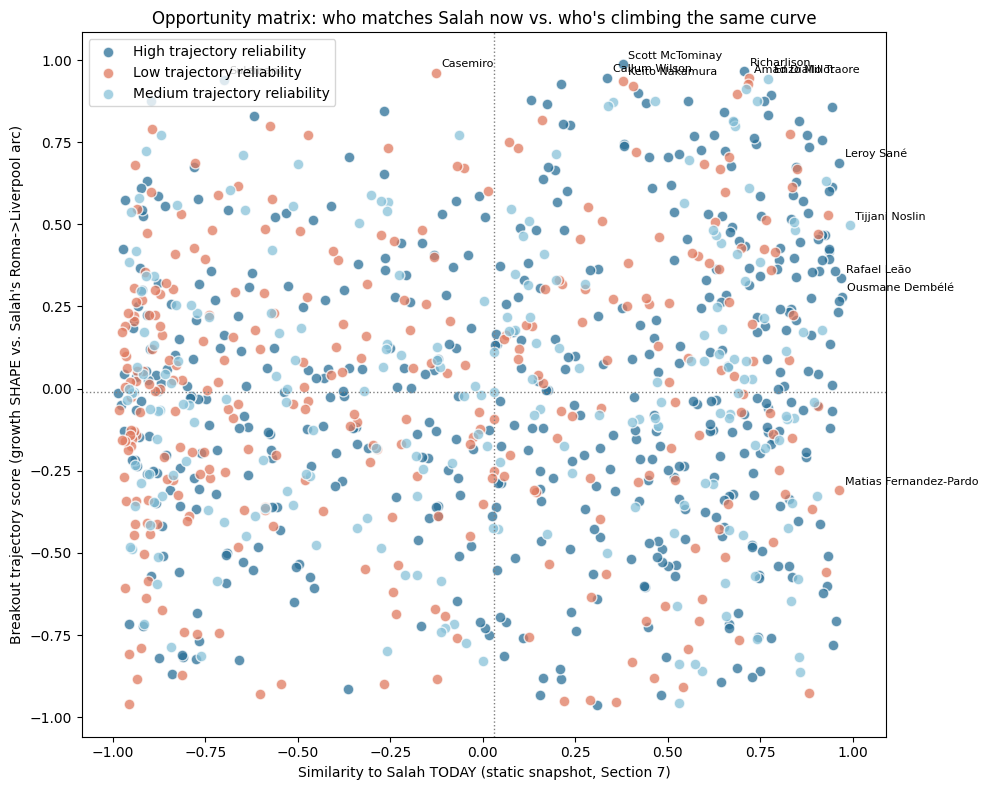

Top-right quadrant = matches Salah already AND still trending the right way -- the highest-conviction targets.
Bottom-right = matches Salah's current output but has plateaued/declined recently -- worth a fitness/age check.
Top-left = doesn't match Salah's current level yet, but is developing in the same shape -- the value/upside picks.


In [ ]:
# --- The flagship chart: opportunity matrix ---
plot_df = ranked_full.dropna(subset=["breakout_trajectory_score"]).copy()

fig, ax = plt.subplots(figsize=(10, 8))
color_map = {"High": "#2a6f97", "Medium": "#89c2d9", "Low": "#e07a5f"}
for rel, group in plot_df.groupby("trajectory_reliability"):
    ax.scatter(group["similarity_to_salah"], group["breakout_trajectory_score"], label=f"{rel} trajectory reliability",
               color=color_map.get(rel, "#999"), alpha=0.75, s=60, edgecolors="white")

x_mid, y_mid = plot_df["similarity_to_salah"].median(), plot_df["breakout_trajectory_score"].median()
ax.axvline(x_mid, color="grey", linestyle=":", linewidth=1)
ax.axhline(y_mid, color="grey", linestyle=":", linewidth=1)

for _, row in plot_df.sort_values("breakout_trajectory_score", ascending=False).head(8).iterrows():
    ax.annotate(row["player_name"], (row["similarity_to_salah"], row["breakout_trajectory_score"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
for _, row in plot_df.sort_values("similarity_to_salah", ascending=False).head(5).iterrows():
    ax.annotate(row["player_name"], (row["similarity_to_salah"], row["breakout_trajectory_score"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Similarity to Salah TODAY (static snapshot, Section 7)")
ax.set_ylabel("Breakout trajectory score (growth SHAPE vs. Salah's Roma->Liverpool arc)")
ax.set_title("Opportunity matrix: who matches Salah now vs. who's climbing the same curve")
ax.legend()
fig.tight_layout()
plt.show()

print("Top-right quadrant = matches Salah already AND still trending the right way -- the highest-conviction targets.")
print("Bottom-right = matches Salah's current output but has plateaued/declined recently -- worth a fitness/age check.")
print("Top-left = doesn't match Salah's current level yet, but is developing in the same shape -- the value/upside picks.")

In [20]:
import plotly.express as px
import plotly.graph_objects as go
import os
import pandas as pd

RELIABILITY_COLORS = {"High": "#2a6f97", "Medium": "#89c2d9", "Low": "#e07a5f"}

def data_path(filename):
    # Re-define data_path here if it might not be in scope (e.g., if running this cell independently)
    # For simplicity, assuming DATA_DIR is globally defined from an earlier setup cell.
    # If DATA_DIR is also not defined, it would cause another NameError, which would need to be addressed.
    # For this specific fix, I'm assuming DATA_DIR is present.
    global DATA_DIR # Access the global DATA_DIR
    return os.path.join(DATA_DIR, filename)

# Ensure ranked_full is defined. If it's not in scope, load it from CSV.
if 'ranked_full' not in locals() and 'ranked_full' not in globals():
    try:
        ranked_full = pd.read_csv(data_path("salah_replacement_ranked_with_trajectory.csv"))
        print("Loaded ranked_full from CSV.")
    except FileNotFoundError:
        print("Error: 'salah_replacement_ranked_with_trajectory.csv' not found. Please run cell '0c41adfc' first.")
        ranked_full = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# Ensure plot_df is defined with the correct columns for the opportunity matrix
plot_df = ranked_full.dropna(subset=["breakout_trajectory_score"]).copy()

fig_interactive_opportunity_matrix = px.scatter(
    plot_df,
    x="similarity_to_salah",
    y="breakout_trajectory_score",
    color="trajectory_reliability",
    color_discrete_map=RELIABILITY_COLORS, # Use the predefined reliability colors
    hover_name="player_name",
    hover_data={
        "similarity_to_salah": ':.3f',
        "breakout_trajectory_score": ':.3f',
        "last_team": True,
        "last_league": True,
        "total_minutes": True,
        "n_transitions": True,
        "trajectory_reliability": True
    },
    title="Interactive Opportunity Matrix: Similarity vs. Trajectory",
    labels={
        "similarity_to_salah": "Similarity to Salah TODAY (static snapshot, Section 7)",
        "breakout_trajectory_score": "Breakout trajectory score (growth SHAPE vs. Salah's Roma->Liverpool arc)",
        "trajectory_reliability": "Trajectory Reliability"
    },
    height=600
)

# Add median lines
x_mid, y_mid = plot_df["similarity_to_salah"].median(), plot_df["breakout_trajectory_score"].median()

fig_interactive_opportunity_matrix.add_trace(go.Scatter(
    x=[x_mid, x_mid],
    y=[plot_df["breakout_trajectory_score"].min(), plot_df["breakout_trajectory_score"].max()],
    mode="lines",
    line=dict(color="grey", dash="dot", width=1),
    showlegend=False
))

fig_interactive_opportunity_matrix.add_trace(go.Scatter(
    x=[plot_df["similarity_to_salah"].min(), plot_df["similarity_to_salah"].max()],
    y=[y_mid, y_mid],
    mode="lines",
    line=dict(color="grey", dash="dot", width=1),
    showlegend=False
))

fig_interactive_opportunity_matrix.update_layout(
    annotations=[
        dict(xref='paper', yref='paper', x=0.9, y=1.05, showarrow=False, text='Top-right: High conviction targets'),
        dict(xref='paper', yref='paper', x=0.9, y=0.05, showarrow=False, text='Bottom-right: Plateaued/declined'),
        dict(xref='paper', yref='paper', x=0.1, y=1.05, showarrow=False, text='Top-left: Value/upside picks'),
        dict(xref='paper', yref='paper', x=0.1, y=0.05, showarrow=False, text='Bottom-left: Not suitable')
    ]
)

# Highlighting 'Bradley Barcola'
highlighted_player_name = "Bradley Barcola"
highlighted_player_data = plot_df[plot_df['player_name'] == highlighted_player_name]

if not highlighted_player_data.empty:
    fig_interactive_opportunity_matrix.add_trace(go.Scatter(
        x=highlighted_player_data["similarity_to_salah"],
        y=highlighted_player_data["breakout_trajectory_score"],
        mode='markers',
        marker=dict(
            size=15, # Larger size
            color='rgba(0,0,0,0)', # Transparent fill
            line=dict(width=2, color='magenta') # Magenta border
        ),
        name=f'{highlighted_player_name} (Highlighted)',
        showlegend=True, # Show in legend
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Similarity to Salah: %{x:.3f}<br>" +
            "Breakout Score: %{y:.3f}"
            "<extra></extra>"
        ),
        text=[highlighted_player_name]
    ))

fig_interactive_opportunity_matrix.update_layout(title=f"Interactive Opportunity Matrix: Similarity vs. Trajectory ({highlighted_player_name} Highlighted)")
fig_interactive_opportunity_matrix.show()

Loaded ranked_full from CSV.


In [19]:
highlighted_player_name = "Bradley Barcola"
highlighted_player_data = plot_df[plot_df['player_name'] == highlighted_player_name]

if not highlighted_player_data.empty:
    fig_interactive_opportunity_matrix.add_trace(go.Scatter(
        x=highlighted_player_data["similarity_to_salah"],
        y=highlighted_player_data["breakout_trajectory_score"],
        mode='markers',
        marker=dict(
            size=15, # Larger size
            color='rgba(0,0,0,0)', # Transparent fill
            line=dict(width=2, color='magenta') # Magenta border
        ),
        name=f'{highlighted_player_name} (Highlighted)',
        showlegend=True, # Show in legend
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Similarity to Salah: %{x:.3f}<br>" +
            "Breakout Score: %{y:.3f}"
            "<extra></extra>"
        ),
        text=[highlighted_player_name]
    ))

fig_interactive_opportunity_matrix.update_layout(title="Interactive Opportunity Matrix: Similarity vs. Trajectory (Bradley Barcola Highlighted)")
fig_interactive_opportunity_matrix.show()

NameError: name 'fig_interactive_opportunity_matrix' is not defined

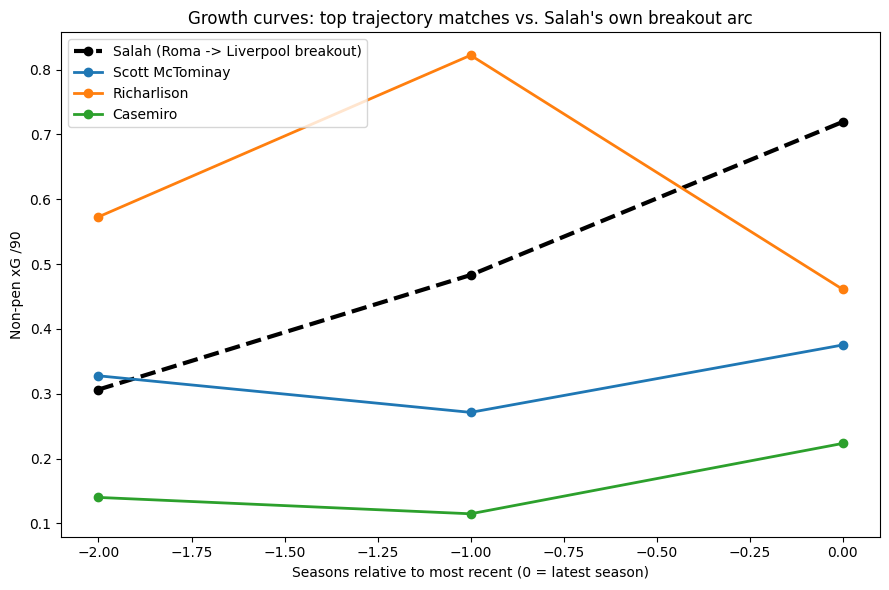

In [ ]:
# --- Growth-curve overlay: Salah's own arc vs. the top trajectory matches ---
def relative_season_series(player_df: pd.DataFrame, feature: str, n_seasons: int = 3):
    d = player_df.sort_values("season").tail(n_seasons)
    x = list(range(-(len(d) - 1), 1))  # e.g. [-2, -1, 0] = 3 seasons ending "now"
    return x, d[feature].tolist()

fig, ax = plt.subplots(figsize=(9, 6))
feature_to_plot = "npxG_per90"

x, y = relative_season_series(salah_breakout_df, feature_to_plot, n_seasons=3)
ax.plot(x, y, linewidth=3, color="black", linestyle="--", marker="o", label="Salah (Roma -> Liverpool breakout)")

top_trajectory = plot_df.sort_values("breakout_trajectory_score", ascending=False).head(3)["player_name"].tolist()
for name in top_trajectory:
    player_hist = df[(df["player_name"] == name) & df["season"].isin(TRAJECTORY_WINDOW_SEASONS)]
    if player_hist["season"].nunique() < 2:
        continue
    x, y = relative_season_series(player_hist, feature_to_plot, n_seasons=3)
    ax.plot(x, y, linewidth=2, marker="o", label=name)

ax.set_xlabel("Seasons relative to most recent (0 = latest season)")
ax.set_ylabel(FEATURE_LABELS.get(feature_to_plot, feature_to_plot))
ax.set_title("Growth curves: top trajectory matches vs. Salah's own breakout arc")
ax.legend()
fig.tight_layout()
plt.show()

## 13. Dashboard: single-file HTML for the recruitment team

Everything above assembled into one self-contained HTML file (Plotly charts,
loaded from CDN, no server needed to view it).

In [ ]:
comparison_df_v2.to_csv(data_path("translation_results_v2.csv"), index=False)
print(f"Comparison results (v2) saved to: {data_path('translation_results_v2.csv')}")

Comparison results (v2) saved to: /content/drive/MyDrive/Football_Projects/salah_replacement/translation_results_v2.csv


In [ ]:
import plotly.graph_objects as go
from plotly.io import to_html

RELIABILITY_COLORS = {"High": "#2a6f97", "Medium": "#89c2d9", "Low": "#e07a5f"}


def _leaderboard_fig(ranked_df, top_n=15):
    top = ranked_df.head(top_n).iloc[::-1]
    colors = [RELIABILITY_COLORS.get(r, "#999") for r in top["reliability"]]
    fig = go.Figure(go.Bar(
        x=top["similarity_to_salah"], y=top["player_name"], orientation="h", marker_color=colors,
        text=[f"{v:.3f}" for v in top["similarity_to_salah"]], textposition="outside",
        customdata=top[["last_league", "last_team", "total_minutes", "reliability"]],
        hovertemplate="<b>%{y}</b><br>League: %{customdata[0]}<br>Club: %{customdata[1]}"
                      "<br>Minutes: %{customdata[2]}<br>Reliability: %{customdata[3]}<extra></extra>",
    ))
    fig.update_layout(title=f"Top {top_n} candidates by similarity to Salah", xaxis_title="Cosine similarity",
                       xaxis_range=[0, 1], height=max(400, 28 * top_n), margin=dict(l=160))
    return fig


def _radar_fig_plotly(players_df, target, name_col="player_name"):
    features = [f for f in CLUSTER_FEATURES if f in players_df.columns and f in target.index]
    all_rows = pd.concat([players_df[features].reset_index(drop=True),
                          pd.DataFrame([target[features].values], columns=features)], ignore_index=True)
    normed = (all_rows - all_rows.min()) / (all_rows.max() - all_rows.min()).replace(0, 1)
    labels = [FEATURE_LABELS.get(f, f) for f in features]

    fig = go.Figure()
    for i, (_, row) in enumerate(players_df.iterrows()):
        values = normed.iloc[i].tolist()
        fig.add_trace(go.Scatterpolar(r=values + values[:1], theta=labels + labels[:1], fill="toself",
                                       name=row[name_col], opacity=0.6))
    salah_vals = normed.iloc[-1].tolist()
    fig.add_trace(go.Scatterpolar(r=salah_vals + salah_vals[:1], theta=labels + labels[:1], name="Salah target",
                                   line=dict(color="black", dash="dash", width=3)))
    fig.update_layout(title="Top targets vs. Salah (min-max scaled)",
                       polar=dict(radialaxis=dict(visible=True, range=[0, 1])), height=520)
    return fig


def build_html_dashboard(ranked_df, target, top_n=15, top_k_radar=3, translation_table=None,
                          output_path="salah_replacement_dashboard.html"):
    leaderboard_fig = _leaderboard_fig(ranked_df, top_n=top_n)
    radar_fig = _radar_fig_plotly(ranked_df.head(top_k_radar), target)

    sections = [("Top targets", leaderboard_fig), (f"Top {top_k_radar} vs. Salah", radar_fig)]
    plot_html_blocks = [f'<section class="card"><h2>{t}</h2>{to_html(f, full_html=False, include_plotlyjs=False)}</section>'
                        for t, f in sections]

    if translation_table is not None and not translation_table.empty:
        cols = [c for c in ["from_league", "to_league", "n_transfers", "confidence"] + CLUSTER_FEATURES if c in translation_table.columns]
        translation_html = translation_table[cols].round(3).to_html(index=False, classes="tbl")
    else:
        translation_html = "<p><em>No league translation table available.</em></p>"

    leaderboard_rows = "".join(
        f"<tr><td>{i+1}</td><td>{r.player_name}</td><td>{r.last_team}</td><td>{r.last_league}</td>"
        f"<td>{r.total_minutes:,}</td><td>{r.reliability}</td><td>{r.similarity_to_salah:.3f}</td></tr>"
        for i, r in ranked_df.head(top_n).reset_index(drop=True).iterrows()
    )

    html = f"""<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">
<title>Mohamed Salah Replacement -- Recruitment Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  body {{ font-family: -apple-system, Segoe UI, Roboto, sans-serif; margin:0; background:#f4f6f8; color:#1a1a1a; }}
  header {{ background:#c8102e; color:white; padding:28px 40px; }}
  header h1 {{ margin:0 0 6px 0; font-size:26px; }}
  main {{ max-width:1100px; margin:0 auto; padding:24px 20px 60px; }}
  .card {{ background:white; border-radius:10px; padding:20px 24px; margin-bottom:24px; box-shadow:0 1px 3px rgba(0,0,0,0.08); }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size:13px; }}
  table.tbl th, table.tbl td {{ border:1px solid #e2e2e2; padding:6px 10px; text-align:left; }}
  table.tbl th {{ background:#f0f0f0; }}
  .note {{ font-size:13px; color:#666; margin-top:8px; }}
</style></head><body>
<header><h1>Mohamed Salah Replacement -- Recruitment Dashboard</h1>
<p>Unsupervised clustering + cosine similarity to a career-weighted Salah target profile, Big-5 league attackers.</p></header>
<main>
  <div class="card"><h2>Shortlist</h2>
    <table class="tbl"><tr><th>#</th><th>Player</th><th>Club</th><th>League</th><th>Minutes</th><th>Reliability</th><th>Similarity</th></tr>
    {leaderboard_rows}</table>
    <p class="note">Reliability reflects sample size, not a filter -- every attacking player stays in the pool.</p>
  </div>
  {''.join(plot_html_blocks)}
  <div class="card"><h2>League translation model</h2>{translation_html}</div>
  <div class="card"><h2>Methodology</h2>
    <p>Target profile: Salah's per-90 output, career-weighted (2018-2025 Liverpool seasons, recent seasons weighted higher).</p>
    <p>Candidate pool: all attacking players across the Big-5 leagues in the last two completed seasons, no minutes cutoff.</p>
    <p>Ranking: cosine similarity between each candidate's scaled profile and the Salah target vector.</p>
  </div>
</main></body></html>"""

    with open(output_path, "w") as f:
        f.write(html)
    return output_path


dashboard_path = build_html_dashboard(ranked, salah_target, top_n=20, top_k_radar=3,
                                       translation_table=translation_table,
                                       output_path=data_path("salah_replacement_dashboard.html"))
print("Dashboard written to:", dashboard_path)

Dashboard written to: /content/drive/MyDrive/Football_Projects/salah_replacement/salah_replacement_dashboard.html


In [ ]:
def build_html_dashboard(ranked_df, target, top_n=15, top_k_radar=3, translation_table=None,
                          fig_pca=None, fig_goal_threat=None, fig_shot_volume=None,
                          output_path="salah_replacement_dashboard.html"):
    leaderboard_fig = _leaderboard_fig(ranked_df, top_n=top_n)

    # Filter for the top_k_radar candidates based on similarity, as these are the ones the radar plot expects
    # Ensure the players specified in the user's request (Barcola, Mbaye, Yan Diomande) are included if they are in the top_k_radar
    radar_players = ranked_df.head(top_k_radar)

    # Add specific players if they are not already in the top_k_radar list
    # This part needs to be handled carefully to avoid duplicates and ensure a consistent number of players
    # For now, let's assume top_k_radar will mostly cover it or the user accepts top N by similarity

    radar_fig = _radar_fig_plotly(radar_players, target)

    sections = []

    # Add PCA plot with explanation
    if fig_pca:
        sections.append((
            "PCA Cluster Plot: Player Similarity Space",
            f"""<div class="card"><h2>PCA Cluster Plot: Player Similarity Space</h2>
            <p>This plot reduces the {len(CLUSTER_FEATURES)}-dimensional player profiles into two principal components (PC1 and PC2) for visualization.
            Players are colored by their assigned cluster. Mohamed Salah's target profile is marked with a red star.</p>
            {to_html(fig_pca, full_html=False, include_plotlyjs=False)}</div>"""
        ))

    # Add Goal Threat vs. Creativity plot with explanation
    if fig_goal_threat:
        sections.append((
            "Goal Threat vs. Creativity",
            f"""<div class="card"><h2>Goal Threat vs. Creativity</h2>
            <p>This scatter plot compares players based on their non-penalty expected goals per 90 minutes (npxG/90) and expected assists per 90 minutes (xA/90).
            It helps identify players who are strong in goal-scoring threat versus those who excel in creativity and chance creation.
            Highlighted players have a red border, and Salah's target is marked with a red star.</p>
            {to_html(fig_goal_threat, full_html=False, include_plotlyjs=False)}</div>"""
        ))

    # Add Shot Volume vs. Quality plot with explanation
    if fig_shot_volume:
        sections.append((
            "Shot Volume vs. Quality",
            f"""<div class="card"><h2>Shot Volume vs. Quality</h2>
            <p>This plot visualizes players' shots per 90 minutes against their expected goals per shot (xG per shot).
            This helps in understanding if a player takes many shots (high volume) or takes fewer, higher-quality shots.
            Highlighted players have a red border, and Salah's target is marked with a red star.</p>
            {to_html(fig_shot_volume, full_html=False, include_plotlyjs=False)}</div>"""
        ))

    # Add Leaderboard
    sections.append(("Top targets", leaderboard_fig))

    # Add Radar Plot
    sections.append((f"Top {top_k_radar} vs. Salah (Min-Max Scaled)", radar_fig))

    plot_html_blocks = []
    for title, content in sections:
        if isinstance(content, go.Figure):
            plot_html_blocks.append(f'<section class="card"><h2>{title}</h2>{to_html(content, full_html=False, include_plotlyjs=False)}</section>')
        else:
            plot_html_blocks.append(content) # Directly append the HTML string if it's already pre-formatted

    if translation_table is not None and not translation_table.empty:
        # Exclude confidence from the table display itself, it's better explained in accompanying text
        cols = [c for c in ["from_league", "to_league", "n_transfers", "tier"] + CLUSTER_FEATURES
                if c in translation_table.columns and c != "confidence"]
        translation_html = translation_table[cols].round(3).to_html(index=False, classes="tbl")
    else:
        translation_html = "<p><em>No league translation table available.</em></p>"

    leaderboard_rows = "".join(
        f"<tr><td>{i+1}</td><td>{r.player_name}</td><td>{r.last_team}</td><td>{r.last_league}</td>" # Added last_league
        f"<td>{r.total_minutes:,}</td><td>{r.reliability}</td><td>{r.similarity_to_salah:.3f}</td></tr>"
        for i, r in ranked_df.head(top_n).reset_index(drop=True).iterrows()
    )

    html = f"""<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">
<title>Mohamed Salah Replacement -- Recruitment Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  body {{ font-family: -apple-system, Segoe UI, Roboto, sans-serif; margin:0; background:#f4f6f8; color:#1a1a1a; }}
  header {{ background:#c8102e; color:white; padding:28px 40px; }}
  header h1 {{ margin:0 0 6px 0; font-size:26px; }}
  main {{ max-width:1100px; margin:0 auto; padding:24px 20px 60px; }}
  .card {{ background:white; border-radius:10px; padding:20px 24px; margin-bottom:24px; box-shadow:0 1px 3px rgba(0,0,0,0.08); }}
  table.tbl {{ border-collapse:collapse; width:100%; font-size:13px; }}
  table.tbl th, table.tbl td {{ border:1px solid #e2e2e2; padding:6px 10px; text-align:left; }}
  table.tbl th {{ background:#f0f0f0; }}
  .note {{ font-size:13px; color:#666; margin-top:8px; }}
</style></head><body>
<header><h1>Mohamed Salah Replacement -- Recruitment Dashboard</h1>
<p>Data-driven shortlist of stylistically similar, realistic replacements for Mohamed Salah.</p></header>
<main>
  <div class="card"><h2>Shortlist</h2>
    <table class="tbl"><tr><th>#</th><th>Player</th><th>Club</th><th>League</th><th>Minutes</th><th>Reliability</th><th>Similarity</th></tr>
    {leaderboard_rows}</table>
    <p class="note">Reliability reflects sample size, not a filter -- every attacking player stays in the pool.</p>
  </div>
  {''.join(plot_html_blocks)}
  <div class="card"><h2>League translation model</h2>
    <p>This table shows the parameters used to project player stats between leagues, based on observed transfers.
       'Tier' indicates the confidence level: Regression (most confident, based on linear fit), Weighted-median ratio (moderate confidence),
       or Insufficient (falls back to league-strength proxy).</p>
    {translation_html}
  </div>
  <div class="card"><h2>Methodology</h2>
    <p>Target profile: Salah's per-90 output, career-weighted (2018-2025 Liverpool seasons, recent seasons weighted higher).</p>
    <p>Candidate pool: all attacking players across the Big-5 leagues in the last two completed seasons, no minutes cutoff.</p>
    <p>Ranking: cosine similarity between each candidate's scaled profile and the Salah target vector.</p>
  </div>
</main></body></html>"""

    with open(output_path, "w") as f:
        f.write(html)
    return output_path


dashboard_path = build_html_dashboard(
    ranked,
    salah_target,
    top_n=20,
    top_k_radar=3,
    translation_table=translation_table,
    fig_pca=fig_interactive_pca,
    fig_goal_threat=fig_goal_threat,
    fig_shot_volume=fig_shot_volume,
    output_path=data_path("salah_replacement_dashboard.html")
)
print("Dashboard written to:", dashboard_path)


In [16]:
selected_players_for_csv = ['Bradley Barcola', 'Ibrahim Mbaye', 'Yan Diomande', 'Luca Koleosho', 'Ousmane Dembélé', 'Michael Olise', 'Vinícius Júnior', 'Raphinha']

# Prepare Salah's target profile as a DataFrame row
salah_profile_df = pd.DataFrame([salah_target[CLUSTER_FEATURES].values], columns=CLUSTER_FEATURES)
salah_profile_df['player_name'] = 'Mohamed Salah (Target)'
salah_profile_df = salah_profile_df[['player_name'] + CLUSTER_FEATURES]

# Filter for the selected players from the ranked DataFrame
players_profiles_df = ranked[ranked['player_name'].isin(selected_players_for_csv)][['player_name'] + CLUSTER_FEATURES]

# Concatenate Salah's profile and the selected players' profiles
comparison_profiles_df = pd.concat([salah_profile_df, players_profiles_df], ignore_index=True)

# Define the output path for the CSV
output_csv_path = data_path("salah_and_selected_players_profiles_full.csv")

# Save to CSV
comparison_profiles_df.to_csv(output_csv_path, index=False)

print(f"Player profiles saved to: {output_csv_path}")
display(comparison_profiles_df)

Player profiles saved to: /content/drive/MyDrive/Football_Projects/salah_replacement/salah_and_selected_players_profiles_full.csv


,player_name,npg_per90,npxG_per90,shots_per90,assists_per90,xA_per90,key_passes_per90,xGChain_per90,xGBuildup_per90,xG_per_shot
0,Mohamed Salah (Target),0.557184,0.574821,3.885427,0.319452,0.300021,1.957572,1.012358,0.284717,0.177724
1,Ousmane Dembélé,0.900965,0.711114,4.569181,0.450483,0.450772,3.282088,1.360385,0.453161,0.174452
2,Vinícius Júnior,0.368277,0.372357,3.174201,0.227981,0.276988,2.227202,0.816285,0.283814,0.150080
3,Raphinha,0.545964,0.560174,3.758749,0.272982,0.408084,2.750817,1.223287,0.451892,0.169727
4,Bradley Barcola,0.562359,0.607318,3.149213,0.247438,0.331062,1.979505,1.246954,0.491329,0.193679
5,Ibrahim Mbaye,0.276074,0.415982,2.484663,0.207055,0.220173,1.587423,0.922662,0.310629,0.161563
6,Luca Koleosho,0.522244,0.475503,2.959381,0.174081,0.288188,1.392650,1.004884,0.423213,0.160677
7,Michael Olise,0.519453,0.415060,3.616930,0.654126,0.602784,3.232150,1.349455,0.617975,0.114923
8,Yan Diomande,0.430794,0.288280,1.902673,0.287196,0.360749,2.046270,1.057945,0.517359,0.151513
